# ASSISTments — Common-Data, Leakage-Aware Hybrid Sequential Recommendation

## Dissertation-strength publication notebook

This notebook rebuilds the ASSISTments experiment so that it follows the same methodological safeguards used in the EdNet KT4 and corrected RetailRocket studies.

### Core design

- one **training-information-only common learner cohort**
- the **same bounded training histories** for CF, RF, GRU4Rec, SASRec and BERT4Rec-style
- per-learner **chronological leave-two-out**
- one frozen **model-independent 1-positive + 99-negative candidate cache**
- validation-only reliability estimation and component selection
- XGBoost learning-to-rank fusion with the final test opened only after design choices are frozen
- visitor-level bootstrap confidence intervals
- paired Wilcoxon tests, Holm correction and rank-biserial effect size
- **five-seed retrained leave-one-component-out ablation**
- popularity controls
- SHAP attribution
- history-length robustness
- controlled neural training-data scaling sensitivity
- computational efficiency and model-size profiling
- executable common-cohort, leakage and reproducibility gates

### Important ASSISTments-specific point

The public Skill Builder file contains fewer learners than EdNet KT4 or RetailRocket. Therefore the notebook does **not invent a 50,000-learner cohort**. It first performs the chronological split and retains every learner with at least two training interactions. If that eligible population exceeds the configured ceiling, deterministic proportional stratified sampling is used. With the dataset version used in the earlier notebook, this procedure is expected to produce approximately 3,840 common learners, but the executed notebook prints and hashes the exact number.

In [1]:
# ============================================================
# 1. IMPORTS, REPRODUCIBILITY AND GLOBAL CONFIGURATION
# ============================================================
import os, gc, time, math, random, pickle, tempfile, warnings
import hashlib, json, platform, sys, subprocess
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from scipy.stats import wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests

from xgboost import XGBRanker

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_NAME = "assistments_common_cohort"
DATA_PATH = "/kaggle/input/datasets/nanaboadu/assistments/skill_builder_data.csv"
OUT_DIR = Path("/kaggle/working/assistments_common_cohort_publication_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------
# Common-data design
# --------------------------
COMMON_LEARNER_CAP = 50_000
COMMON_MAX_HISTORY = 50
MAX_PREFIXES_PER_LEARNER = 2
MAX_EVAL_USERS = 5_000
NEGATIVES_PER_QUERY = 99
TOPK = 10
MIN_TOTAL_EVENTS = 3
MIN_COMMON_TRAIN_EVENTS = 2

# The validation split is divided 80/20 for ranker fitting vs component selection.
VALIDATION_SELECTION_FRACTION = 0.20

# --------------------------
# Constituent-model budgets
# --------------------------
RF_NEGATIVES_PER_POSITIVE = 1
RF_TREES = 120
RF_MAX_DEPTH = 10
RF_MIN_LEAF = 5

GRU_MAX_LEN = 30
GRU_EMBED = 32
GRU_HIDDEN = 32
GRU_BATCH = 32
GRU_EPOCHS = 15

SAS_MAX_LEN = 30
SAS_HIDDEN = 48
SAS_HEADS = 2
SAS_LAYERS = 1
SAS_BATCH = 64
SAS_EPOCHS = 15

BERT_MAX_LEN = 30
BERT_HIDDEN = 32
BERT_HEADS = 2
BERT_LAYERS = 1
BERT_BATCH = 24
BERT_EPOCHS = 15

# --------------------------
# Validation-frozen XGBRanker
# --------------------------
RANKER_PARAMS = dict(
    objective="rank:ndcg",
    eval_metric="ndcg@10",
    n_estimators=300,
    learning_rate=0.035,
    max_depth=5,
    min_child_weight=8,
    subsample=0.80,
    colsample_bytree=0.80,
    reg_alpha=1.5,
    reg_lambda=10.0,
    gamma=0.15,
    tree_method="hist",
    n_jobs=4,
)

# --------------------------
# Reviewer-hardening analyses
# --------------------------
RUN_SHAP = True
RUN_SCALING_DIAGNOSTIC = True
SCALING_FRACTIONS = [0.25, 0.50, 1.00]
SCALING_EPOCHS = 6
SCALING_EVAL_USERS = 1_000
ABLATION_SEEDS = [42, 59, 73, 89, 115]

print("Dataset:", DATASET_NAME)
print("Path:", DATA_PATH)
print("Device:", DEVICE)
print("Common learner ceiling:", f"{COMMON_LEARNER_CAP:,}")
print("Common history cap:", COMMON_MAX_HISTORY)
print("Max supervised prefixes per learner:", MAX_PREFIXES_PER_LEARNER)
print("Output directory:", OUT_DIR)

Dataset: assistments_common_cohort
Path: /kaggle/input/datasets/nanaboadu/assistments/skill_builder_data.csv
Device: cuda
Common learner ceiling: 50,000
Common history cap: 50
Max supervised prefixes per learner: 2
Output directory: /kaggle/working/assistments_common_cohort_publication_outputs


## Execution guidance

Run this notebook from a fresh Kaggle kernel from the first cell to the last cell. Because the common cohort, candidate caches, fusion selection and inferential analyses are linked, results from an earlier ASSISTments run must not be mixed with outputs from this notebook.

The final validity gate intentionally stops execution if any baseline family does not consume the same common learner set.

In [2]:
# ============================================================
# 2. ASSISTMENTS LOADING AND PREPROCESSING
# ============================================================
def load_csv_robust(path):
    encodings = ["utf-8", "latin1", "cp1252", "ISO-8859-1"]
    last_error = None
    for enc in encodings:
        try:
            d = pd.read_csv(path, encoding=enc, low_memory=False)
            print("CSV encoding:", enc)
            return d
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"Could not load ASSISTments CSV. Last error: {last_error}")

if not os.path.exists(DATA_PATH):
    matches = list(Path("/kaggle/input").rglob("skill_builder_data.csv"))
    if not matches:
        raise FileNotFoundError(
            f"ASSISTments file not found at {DATA_PATH} and no fallback copy was found."
        )
    DATA_PATH = str(matches[0])
    print("Using fallback path:", DATA_PATH)

raw = load_csv_robust(DATA_PATH)
raw_rows = len(raw)
raw_users = raw["user_id"].nunique(dropna=True) if "user_id" in raw else np.nan
raw_items = raw["problem_id"].nunique(dropna=True) if "problem_id" in raw else np.nan

required = ["user_id", "problem_id", "order_id", "correct"]
missing = [c for c in required if c not in raw.columns]
if missing:
    raise ValueError(f"Missing required ASSISTments columns: {missing}")

keep = required.copy()
for optional in ["skill_id", "skill_name"]:
    if optional in raw.columns:
        keep.append(optional)

df = raw[keep].copy()
df = df.rename(columns={
    "problem_id": "item_id",
    "order_id": "timestamp",
})

for c in ["user_id", "item_id", "timestamp", "correct"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["user_id", "item_id", "timestamp", "correct"]).copy()
df["user_id"] = df["user_id"].astype(np.int64)
df["item_id"] = df["item_id"].astype(np.int64)
df["timestamp"] = df["timestamp"].astype(np.int64)
df["correct"] = df["correct"].astype(np.int8)
df = df[df["correct"].isin([0, 1])].copy()

# Remove only exact repeated records. Repeated attempts on the same problem at
# different order positions remain valid learning interactions.
dedup_subset = ["user_id", "item_id", "timestamp", "correct"]
df = (
    df.drop_duplicates(subset=dedup_subset)
      .sort_values(["user_id", "timestamp", "item_id"])
      .reset_index(drop=True)
)

processed_rows = len(df)

print("Raw rows:", f"{raw_rows:,}")
print("Raw users:", f"{int(raw_users):,}" if pd.notna(raw_users) else "NA")
print("Raw items:", f"{int(raw_items):,}" if pd.notna(raw_items) else "NA")
print("Rows after preprocessing:", f"{processed_rows:,}")
display(df.head())

CSV encoding: latin1
Raw rows: 525,534
Raw users: 4,217
Raw items: 26,688
Rows after preprocessing: 346,860


,user_id,item_id,timestamp,correct,skill_id,skill_name
0,14,93383,21617623,0,2.0,Circle Graph
1,14,93407,21617632,1,2.0,Circle Graph
2,14,93400,21617641,0,2.0,Circle Graph
3,14,93419,21617650,0,2.0,Circle Graph
4,14,93420,21617659,0,2.0,Circle Graph


In [3]:
# ============================================================
# 3. ENCODING + CHRONOLOGICAL LEAVE-TWO-OUT ON THE FULL ELIGIBLE SET
# ============================================================
user_enc = LabelEncoder()
item_enc = LabelEncoder()

df["user_idx"] = user_enc.fit_transform(df["user_id"]).astype(np.int64)
df["item_idx"] = (item_enc.fit_transform(df["item_id"]) + 1).astype(np.int64)

# 0 is reserved for neural padding.
n_items = int(df["item_idx"].max()) + 1

# At least three total events are required for leave-two-out.
counts_total = df.groupby("user_idx").size()
eligible_for_split = counts_total[counts_total >= MIN_TOTAL_EVENTS].index
split_source = df[df["user_idx"].isin(eligible_for_split)].copy()

def leave_two_out_split(data):
    ordered = data.sort_values(["user_idx", "timestamp", "item_idx"]).copy()
    last2 = ordered.groupby("user_idx", sort=False, group_keys=False).tail(2)
    test_idx = last2.groupby("user_idx", sort=False, group_keys=False).tail(1).index
    val_idx = last2.drop(index=test_idx).index

    train = ordered.drop(index=np.concatenate([val_idx.to_numpy(), test_idx.to_numpy()])).copy()
    val = ordered.loc[val_idx].copy()
    test = ordered.loc[test_idx].copy()

    return (
        train.reset_index(drop=True),
        val.reset_index(drop=True),
        test.reset_index(drop=True),
    )

full_train_all, full_val_all, full_test_all = leave_two_out_split(split_source)

train_lengths = (
    full_train_all.groupby("user_idx")
    .size()
    .rename("train_len")
    .reset_index()
)

# A learner must have at least two training interactions so that every baseline
# family receives real training evidence and contributes at least one supervised prefix.
eligible_common = train_lengths[
    train_lengths["train_len"] >= MIN_COMMON_TRAIN_EVENTS
].copy()

eligible_common["stratum"] = pd.cut(
    eligible_common["train_len"],
    bins=[1, 5, 20, 50, 100, np.inf],
    labels=["2-5", "6-20", "21-50", "51-100", ">100"],
    include_lowest=True,
)

print("Encoded users before common-cohort restriction:", df["user_idx"].nunique())
print("Encoded items incl. padding:", n_items)
print("Leave-two-out training rows:", f"{len(full_train_all):,}")
print("Validation targets:", f"{len(full_val_all):,}")
print("Test targets:", f"{len(full_test_all):,}")
print("Learners eligible for a shared >=2-event training cohort:", f"{len(eligible_common):,}")

Encoded users before common-cohort restriction: 4217
Encoded items incl. padding: 26689
Leave-two-out training rows: 338,546
Validation targets: 3,930
Test targets: 3,930
Learners eligible for a shared >=2-event training cohort: 3,840


In [4]:
# ============================================================
# 4. TRAINING-ONLY COMMON LEARNER COHORT + BOUNDED COMMON HISTORIES
# ============================================================
def proportional_stratified_sample(frame, target_n, seed):
    if len(frame) <= target_n:
        return np.sort(frame["user_idx"].to_numpy(dtype=np.int64))

    rr = np.random.default_rng(seed)
    chosen = []

    # Floor allocation followed by deterministic remainder filling.
    for _, g in frame.groupby("stratum", observed=False):
        if len(g) == 0:
            continue
        quota = int(np.floor(target_n * len(g) / len(frame)))
        quota = min(quota, len(g))
        if quota > 0:
            take = rr.choice(
                g["user_idx"].to_numpy(dtype=np.int64),
                size=quota,
                replace=False
            )
            chosen.extend(map(int, take))

    chosen = list(dict.fromkeys(chosen))
    remaining = target_n - len(chosen)

    if remaining > 0:
        pool = frame.loc[
            ~frame["user_idx"].isin(chosen), "user_idx"
        ].to_numpy(dtype=np.int64)
        extra = rr.choice(pool, size=remaining, replace=False)
        chosen.extend(map(int, extra))

    return np.sort(np.asarray(chosen[:target_n], dtype=np.int64))

COMMON_LEARNERS = min(COMMON_LEARNER_CAP, len(eligible_common))
common_users = proportional_stratified_sample(
    eligible_common, COMMON_LEARNERS, SEED + 17
)

assert len(common_users) == COMMON_LEARNERS
assert len(np.unique(common_users)) == COMMON_LEARNERS

# Preserve the latest COMMON_MAX_HISTORY training interactions for every selected learner.
common_train_df = (
    full_train_all[full_train_all["user_idx"].isin(common_users)]
    .sort_values(["user_idx", "timestamp", "item_idx"])
    .groupby("user_idx", group_keys=False)
    .tail(COMMON_MAX_HISTORY)
    .reset_index(drop=True)
)

common_counts = common_train_df.groupby("user_idx").size()
assert common_train_df["user_idx"].nunique() == COMMON_LEARNERS
assert int(common_counts.min()) >= MIN_COMMON_TRAIN_EVENTS
assert int(common_counts.max()) <= COMMON_MAX_HISTORY

common_val_df = (
    full_val_all[full_val_all["user_idx"].isin(common_users)]
    .sort_values("user_idx")
    .reset_index(drop=True)
)
common_test_df = (
    full_test_all[full_test_all["user_idx"].isin(common_users)]
    .sort_values("user_idx")
    .reset_index(drop=True)
)

# Chronology gate.
tr_max = common_train_df.groupby("user_idx")["timestamp"].max()
va_t = common_val_df.set_index("user_idx")["timestamp"]
te_t = common_test_df.set_index("user_idx")["timestamp"]
chron_users = tr_max.index.intersection(va_t.index).intersection(te_t.index)

assert (tr_max.loc[chron_users] <= va_t.loc[chron_users]).all()
assert (va_t.loc[chron_users] <= te_t.loc[chron_users]).all()

common_train_seq = (
    common_train_df.groupby("user_idx", sort=True)["item_idx"]
    .apply(lambda x: list(map(int, x)))
    .to_dict()
)
common_correct_seq = (
    common_train_df.groupby("user_idx", sort=True)["correct"]
    .apply(lambda x: list(map(int, x)))
    .to_dict()
)

assert set(common_train_seq) == set(map(int, common_users))
assert set(common_correct_seq) == set(map(int, common_users))

train_catalog = np.sort(common_train_df["item_idx"].unique().astype(np.int64))
train_catalog_set = set(train_catalog.tolist())

# Original learner IDs give a mapping-independent cohort fingerprint.
common_original_users = np.sort(
    common_train_df[["user_idx", "user_id"]]
    .drop_duplicates()
    .sort_values("user_idx")["user_id"]
    .astype(np.int64)
    .to_numpy()
)

COMMON_COHORT_ORIGINAL_SHA256 = hashlib.sha256(
    ",".join(map(str, common_original_users.tolist())).encode("utf-8")
).hexdigest()

COMMON_COHORT_SHA256 = hashlib.sha256(
    ",".join(map(str, common_users.tolist())).encode("utf-8")
).hexdigest()

h = hashlib.sha256()
for uid in common_users:
    items = common_train_seq[int(uid)]
    corr = common_correct_seq[int(uid)]
    h.update(f"{int(uid)}:".encode())
    h.update(",".join(map(str, items)).encode())
    h.update(b"|")
    h.update(",".join(map(str, corr)).encode())
    h.update(b";")
COMMON_HISTORY_SHA256 = h.hexdigest()

def dist_summary(x):
    x = np.asarray(x, dtype=float)
    return {
        "n": len(x),
        "mean": float(x.mean()),
        "median": float(np.median(x)),
        "p25": float(np.quantile(x, .25)),
        "p75": float(np.quantile(x, .75)),
        "p90": float(np.quantile(x, .90)),
        "p99": float(np.quantile(x, .99)),
    }

selected_lengths = eligible_common[
    eligible_common["user_idx"].isin(common_users)
].copy()

distribution_audit = pd.DataFrame([
    {"Population": "All common-eligible", **dist_summary(eligible_common["train_len"])},
    {"Population": "Selected common cohort", **dist_summary(selected_lengths["train_len"])},
])

stratum_audit = pd.concat([
    eligible_common["stratum"].value_counts(normalize=True).rename("Eligible proportion"),
    selected_lengths["stratum"].value_counts(normalize=True).rename("Common proportion"),
], axis=1).fillna(0).sort_index()

display(distribution_audit)
display(stratum_audit)

print("COMMON LEARNERS USED BY EVERY BASELINE:", f"{COMMON_LEARNERS:,}")
print("Common bounded training interactions:", f"{len(common_train_df):,}")
print("Common training catalogue items:", f"{len(train_catalog):,}")
print("COMMON_COHORT_ORIGINAL_SHA256:", COMMON_COHORT_ORIGINAL_SHA256)
print("COMMON_COHORT_SHA256:", COMMON_COHORT_SHA256)
print("COMMON_HISTORY_SHA256:", COMMON_HISTORY_SHA256)

distribution_audit.to_csv(OUT_DIR/"assistments_common_distribution_audit.csv", index=False)
stratum_audit.to_csv(OUT_DIR/"assistments_common_stratum_audit.csv")

,Population,n,mean,median,p25,p75,p90,p99
0,All common-eligible,3840,88.139583,25.5,10.0,83.0,212.0,848.0
1,Selected common cohort,3840,88.139583,25.5,10.0,83.0,212.0,848.0


,Eligible proportion,Common proportion
stratum,,
2-5,0.123177,0.123177
6-20,0.323177,0.323177
21-50,0.218750,0.218750
51-100,0.123177,0.123177
>100,0.211719,0.211719


COMMON LEARNERS USED BY EVERY BASELINE: 3,840
Common bounded training interactions: 108,350
Common training catalogue items: 20,342
COMMON_COHORT_ORIGINAL_SHA256: 5c8fa5a35ad4caba8cd457e51c6a2d157afb045a283416ecfb987ab00e78a67d
COMMON_COHORT_SHA256: 337e693b355639d663b6e9f6b0fb686b9ae543f45c46d73ddc02ae2c97a0e5b5
COMMON_HISTORY_SHA256: f3d962d7f358b25fe0b04b76ef7cbd83dbdd86a6d55fb550d398b84295af5849


In [5]:
# ============================================================
# 5. FROZEN EVALUATION SAMPLE FROM THE COMMON COHORT
# ============================================================
# Held-out targets must be known to the common training catalogue so that
# all baseline families face a meaningful next-item ranking task.

val_known_users = set(
    common_val_df[
        common_val_df["item_idx"].isin(train_catalog_set)
    ]["user_idx"].astype(int)
)
test_known_users = set(
    common_test_df[
        common_test_df["item_idx"].isin(train_catalog_set)
    ]["user_idx"].astype(int)
)

valid_eval_users = np.array(
    sorted(val_known_users & test_known_users),
    dtype=np.int64
)

if len(valid_eval_users) < 2:
    raise ValueError("Too few common-cohort learners have train-known validation and test targets.")

EVAL_USER_COUNT = min(MAX_EVAL_USERS, len(valid_eval_users))

if len(valid_eval_users) <= EVAL_USER_COUNT:
    eval_users = valid_eval_users.copy()
else:
    rng_eval = np.random.default_rng(SEED + 100)
    eval_users = np.sort(
        rng_eval.choice(valid_eval_users, size=EVAL_USER_COUNT, replace=False)
    )

EVAL_USERS_SHA256 = hashlib.sha256(
    ",".join(map(str, eval_users.tolist())).encode("utf-8")
).hexdigest()

val_eval = (
    common_val_df[common_val_df["user_idx"].isin(eval_users)]
    .sort_values("user_idx")
    .reset_index(drop=True)
)
test_eval = (
    common_test_df[common_test_df["user_idx"].isin(eval_users)]
    .sort_values("user_idx")
    .reset_index(drop=True)
)

val_history = {int(u): list(common_train_seq[int(u)]) for u in eval_users}
val_correct_history = {int(u): list(common_correct_seq[int(u)]) for u in eval_users}

val_target_map = dict(zip(
    val_eval["user_idx"].astype(int),
    val_eval["item_idx"].astype(int)
))
val_correct_map = dict(zip(
    val_eval["user_idx"].astype(int),
    val_eval["correct"].astype(int)
))

# At test time the validation interaction is historical information.
test_history = {}
test_correct_history = {}
for uid in eval_users:
    u = int(uid)
    test_history[u] = (
        list(common_train_seq[u]) + [int(val_target_map[u])]
    )[-COMMON_MAX_HISTORY:]
    test_correct_history[u] = (
        list(common_correct_seq[u]) + [int(val_correct_map[u])]
    )[-COMMON_MAX_HISTORY:]

assert len(val_eval) == len(test_eval) == EVAL_USER_COUNT
assert set(val_eval.user_idx.astype(int)) == set(test_eval.user_idx.astype(int))
assert set(eval_users).issubset(set(map(int, common_users)))

eval_audit = pd.DataFrame([
    ["Common cohort learners", COMMON_LEARNERS],
    ["Common bounded training interactions", len(common_train_df)],
    ["Common catalogue items", len(train_catalog)],
    ["Train-known eligible evaluation learners", len(valid_eval_users)],
    ["Frozen evaluation learners", EVAL_USER_COUNT],
], columns=["Statistic", "Value"])

display(eval_audit)
print("EVAL_USERS_SHA256:", EVAL_USERS_SHA256)
eval_audit.to_csv(OUT_DIR/"assistments_common_eval_audit.csv", index=False)

,Statistic,Value
0,Common cohort learners,3840
1,Common bounded training interactions,108350
2,Common catalogue items,20342
3,Train-known eligible evaluation learners,3565
4,Frozen evaluation learners,3565


EVAL_USERS_SHA256: a99d203f34f93a8bbfd9a89d73e22b36cfa63fafe40f37bcc93236d5b4cb3355


In [6]:
# ============================================================
# 6. MODEL-INDEPENDENT CACHED 1+99 CANDIDATE PROTOCOL
# ============================================================
def make_candidate_set(uid, truth, history_map, split_name):
    uid, truth = int(uid), int(truth)
    seen = set(map(int, history_map.get(uid, [])))
    split_offset = 1_000_003 if split_name == "test" else 0
    local_seed = (
        SEED * 10_000_019 + uid * 1009 + truth * 9176 + split_offset
    ) % (2**32 - 1)
    rr = np.random.default_rng(local_seed)

    eligible_negatives = [
        int(x) for x in train_catalog
        if int(x) != truth and int(x) not in seen
    ]

    if len(eligible_negatives) < NEGATIVES_PER_QUERY:
        raise RuntimeError(
            f"User {uid} has only {len(eligible_negatives)} eligible negatives."
        )

    neg = rr.choice(
        np.asarray(eligible_negatives, dtype=np.int64),
        size=NEGATIVES_PER_QUERY,
        replace=False
    )

    candidates = np.concatenate(([truth], neg)).astype(np.int64)
    rr.shuffle(candidates)

    assert len(candidates) == NEGATIVES_PER_QUERY + 1
    assert np.sum(candidates == truth) == 1
    assert len(np.unique(candidates)) == len(candidates)
    assert all(int(x) in train_catalog_set for x in neg)
    assert not any(int(x) in seen for x in neg)

    return candidates

val_candidates = {
    int(r.user_idx): make_candidate_set(
        r.user_idx, r.item_idx, val_history, "validation"
    )
    for r in val_eval.itertuples(index=False)
}

test_candidates = {
    int(r.user_idx): make_candidate_set(
        r.user_idx, r.item_idx, test_history, "test"
    )
    for r in test_eval.itertuples(index=False)
}

# Test negatives may not contain the validation target.
for uid, cand in test_candidates.items():
    truth = int(test_eval.loc[test_eval.user_idx == uid, "item_idx"].iloc[0])
    negatives = set(map(int, cand[cand != truth]))
    assert int(val_target_map[uid]) not in negatives

candidate_audit = pd.DataFrame([
    [
        "Validation",
        len(val_candidates),
        np.mean([len(x) for x in val_candidates.values()]),
        min(map(len, val_candidates.values())),
        max(map(len, val_candidates.values())),
        True
    ],
    [
        "Test",
        len(test_candidates),
        np.mean([len(x) for x in test_candidates.values()]),
        min(map(len, test_candidates.values())),
        max(map(len, test_candidates.values())),
        True
    ],
], columns=[
    "Split", "Queries", "MeanCandidates", "MinCandidates",
    "MaxCandidates", "PositiveExactlyOnce"
])

display(candidate_audit)
candidate_audit.to_csv(
    OUT_DIR/"assistments_common_candidate_protocol.csv",
    index=False
)

,Split,Queries,MeanCandidates,MinCandidates,MaxCandidates,PositiveExactlyOnce
0,Validation,3565,100.0,100,100,True
1,Test,3565,100.0,100,100,True


In [7]:
# ============================================================
# 7. COMMON METRICS, POPULARITY, STATE AND PREFIX HELPERS
# ============================================================
def safe_zscore(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)
    if len(x) == 0:
        return x
    sd = float(np.std(x))
    if not np.isfinite(sd) or sd < 1e-8:
        return np.zeros_like(x)
    z = (x - float(np.mean(x))) / (sd + 1e-12)
    z[~np.isfinite(z)] = 0.0
    return z.astype(np.float32)

def minmax_rank01(x):
    x = np.asarray(x, dtype=np.float32)
    if len(x) <= 1:
        return np.zeros_like(x)
    ranks = pd.Series(x).rank(
        method="average", ascending=True
    ).to_numpy(dtype=np.float32)
    return (ranks - 1.0) / max(len(x) - 1.0, 1.0)

def topk_from_scores(candidates, scores, k=TOPK):
    candidates = np.asarray(candidates, dtype=np.int64)
    scores = np.asarray(scores, dtype=np.float32)
    take = min(k, len(candidates))
    order = np.lexsort((candidates, -scores))[:take]
    return candidates[order].tolist()

def per_query_metrics(preds, truth, k=TOPK):
    preds = list(preds[:k])
    hit = int(int(truth) in preds)
    if hit:
        rank = preds.index(int(truth)) + 1
        ndcg = 1.0 / np.log2(rank + 1)
        mrr = 1.0 / rank
    else:
        ndcg = 0.0
        mrr = 0.0
    return {
        "precision": hit / k,
        "recall": float(hit),
        "hr": float(hit),
        "ndcg": float(ndcg),
        "mrr": float(mrr),
    }

def summarize_user_df(d):
    return d[["precision", "recall", "hr", "ndcg", "mrr"]].mean()

pop_counts = common_train_df["item_idx"].value_counts().to_dict()
max_pop = max(pop_counts.values()) if pop_counts else 1

def pop_log(i):
    return float(np.log1p(pop_counts.get(int(i), 0)))

global_correct_rate = float(common_train_df["correct"].mean())

item_correct_rate = (
    common_train_df.groupby("item_idx")["correct"]
    .mean()
    .to_dict()
)

def correctness_state(correct_history):
    c = list(map(int, correct_history))
    if not c:
        return {
            "last_correct": 0.0,
            "mean_correct": global_correct_rate,
            "recent5_correct": global_correct_rate,
            "correct_streak": 0.0,
        }

    streak = 0
    for x in reversed(c):
        if x == 1:
            streak += 1
        else:
            break

    return {
        "last_correct": float(c[-1]),
        "mean_correct": float(np.mean(c)),
        "recent5_correct": float(np.mean(c[-5:])),
        "correct_streak": float(streak),
    }

def build_prefix_cases(item_map, correct_map, max_prefixes=MAX_PREFIXES_PER_LEARNER):
    cases = []
    for uid in sorted(item_map):
        items = list(map(int, item_map[uid]))
        corr = list(map(int, correct_map[uid]))
        if len(items) < 2:
            continue
        start = max(1, len(items) - max_prefixes)
        for t in range(start, len(items)):
            cases.append(
                (int(uid), items[:t], corr[:t], int(items[t]))
            )
    return cases

common_prefix_cases = build_prefix_cases(
    common_train_seq,
    common_correct_seq
)

common_neural_cases = [
    (uid, prefix_items, target)
    for uid, prefix_items, prefix_correct, target in common_prefix_cases
]

print("Common supervised positive prefix cases:", f"{len(common_prefix_cases):,}")

Common supervised positive prefix cases: 7,584


In [8]:
# ============================================================
# 8. CF — COMMON-COHORT TRAINING-ONLY ITEM CO-OCCURRENCE
# ============================================================
cf_start = time.time()

CF_SOURCE_DF = common_train_df[["user_idx", "item_idx"]].copy()

item_users = (
    CF_SOURCE_DF.groupby("item_idx")["user_idx"]
    .apply(lambda x: set(map(int, pd.unique(x))))
    .to_dict()
)

def cf_score(uid, candidates, history):
    recent = [int(x) for x in history[-10:] if int(x) > 0]
    out = np.zeros(len(candidates), dtype=np.float32)

    for j, c in enumerate(map(int, candidates)):
        cu = item_users.get(c, set())
        sims = []

        for h in recent:
            hu = item_users.get(h, set())
            if cu and hu:
                inter = len(cu & hu)
                if inter:
                    sims.append(
                        inter / math.sqrt(len(cu) * len(hu))
                    )

        out[j] = float(np.mean(sims)) if sims else 0.0
        out[j] += 0.01 * pop_log(c)

    return out

cf_training_users = np.sort(
    CF_SOURCE_DF["user_idx"].unique().astype(np.int64)
)

cf_train_time = time.time() - cf_start
print("CF source rows:", f"{len(CF_SOURCE_DF):,}")
print("CF source learners:", f"{len(cf_training_users):,}")
print(f"CF index construction: {cf_train_time:.2f}s")

CF source rows: 108,350
CF source learners: 3,840
CF index construction: 0.81s


In [9]:
# ============================================================
# 9. RF — PREFIX-SAFE TRAINING ON THE SAME COMMON LEARNERS
# ============================================================
rf_start = time.time()

transitions = Counter()
for uid, seq in common_train_seq.items():
    for a, b in zip(seq[:-1], seq[1:]):
        transitions[(int(a), int(b))] += 1

def rf_feature_row(candidate, prefix_items, prefix_correct):
    candidate = int(candidate)
    last_item = int(prefix_items[-1]) if prefix_items else 0
    state = correctness_state(prefix_correct)

    return {
        "candidate_popularity_log": pop_log(candidate),
        "transition_log": float(
            np.log1p(transitions.get((last_item, candidate), 0))
        ),
        "hist_len": float(len(prefix_items)),
        "last_item_popularity_log": (
            pop_log(last_item) if last_item else 0.0
        ),
        "candidate_success_rate": float(
            item_correct_rate.get(candidate, global_correct_rate)
        ),
        "last_item_success_rate": float(
            item_correct_rate.get(last_item, global_correct_rate)
            if last_item else global_correct_rate
        ),
        **state,
    }

rf_features = [
    "candidate_popularity_log",
    "transition_log",
    "hist_len",
    "last_item_popularity_log",
    "candidate_success_rate",
    "last_item_success_rate",
    "last_correct",
    "mean_correct",
    "recent5_correct",
    "correct_streak",
]

rr = np.random.default_rng(SEED)
rf_rows = []

for uid, prefix_items, prefix_correct, target in tqdm(
    common_prefix_cases,
    desc="RF common-prefix cases"
):
    pos = rf_feature_row(target, prefix_items, prefix_correct)
    pos.update(user_idx=int(uid), label=1)
    rf_rows.append(pos)

    seen = set(map(int, prefix_items))
    used = set()
    negatives = []

    while len(negatives) < RF_NEGATIVES_PER_POSITIVE:
        cand = int(rr.choice(train_catalog))
        if (
            cand != int(target)
            and cand not in seen
            and cand not in used
        ):
            negatives.append(cand)
            used.add(cand)

    for neg in negatives:
        nr = rf_feature_row(neg, prefix_items, prefix_correct)
        nr.update(user_idx=int(uid), label=0)
        rf_rows.append(nr)

rf_train = pd.DataFrame(rf_rows)

rf_model = RandomForestClassifier(
    n_estimators=RF_TREES,
    max_depth=RF_MAX_DEPTH,
    min_samples_leaf=RF_MIN_LEAF,
    class_weight="balanced_subsample",
    random_state=SEED,
    n_jobs=4,
)

rf_model.fit(
    rf_train[rf_features],
    rf_train["label"].astype(int)
)

rf_training_users = np.sort(
    rf_train["user_idx"].unique().astype(np.int64)
)

def rf_score(uid, candidates, history, correct_history=None):
    if correct_history is None:
        correct_history = []
    X = pd.DataFrame([
        rf_feature_row(c, history, correct_history)
        for c in candidates
    ])[rf_features]

    classes = list(rf_model.classes_)
    if 1 not in classes:
        return np.zeros(len(candidates), dtype=np.float32)

    return rf_model.predict_proba(X)[:, classes.index(1)].astype(np.float32)

rf_train_time = time.time() - rf_start

print(f"RF training: {rf_train_time:.2f}s")
print("RF training learners:", f"{len(rf_training_users):,}")
print("RF positive rows:", int((rf_train.label == 1).sum()))
print("RF negative rows:", int((rf_train.label == 0).sum()))

RF common-prefix cases:   0%|          | 0/7584 [00:00<?, ?it/s]

RF training: 1.53s
RF training learners: 3,840
RF positive rows: 7584
RF negative rows: 7584


In [10]:
# ============================================================
# 10. SHARED NEURAL PREFIX DATASET
# ============================================================
class PrefixDataset(Dataset):
    def __init__(self, cases, max_len):
        self.samples = []
        self.max_len = int(max_len)

        for uid, prefix, target in cases:
            p = list(map(int, prefix[-self.max_len:]))
            arr = p + [0] * (self.max_len - len(p))
            self.samples.append(
                (np.asarray(arr, dtype=np.int64), int(target))
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        s, t = self.samples[i]
        return (
            torch.tensor(s, dtype=torch.long),
            torch.tensor(t, dtype=torch.long),
        )

def last_valid_index(seq):
    lengths = (seq != 0).sum(dim=1) - 1
    return torch.clamp(lengths, min=0)

def right_pad(history, max_len):
    h = [int(x) for x in history[-max_len:]]
    return h + [0] * (max_len - len(h))

neural_training_users = np.sort(
    np.asarray(
        sorted({int(uid) for uid, _, _ in common_neural_cases}),
        dtype=np.int64
    )
)

print(
    "Neural/RF positive-case equality:",
    len(common_neural_cases),
    int((rf_train.label == 1).sum())
)

assert len(common_neural_cases) == int((rf_train.label == 1).sum())
assert len(neural_training_users) == COMMON_LEARNERS

Neural/RF positive-case equality: 7584 7584


In [11]:
# ============================================================
# 11. GRU4Rec — COMMON COHORT
# ============================================================
class GRU4RecModel(nn.Module):
    def __init__(self, n_items, embed=GRU_EMBED, hidden=GRU_HIDDEN, dropout=0.20):
        super().__init__()
        self.emb = nn.Embedding(n_items, embed, padding_idx=0)
        self.gru = nn.GRU(embed, hidden, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden, n_items)

    def forward(self, seq):
        out, _ = self.gru(self.emb(seq))
        idx = last_valid_index(seq)
        h = out[
            torch.arange(seq.size(0), device=seq.device),
            idx
        ]
        return self.fc(self.drop(h))

gru_ds = PrefixDataset(common_neural_cases, GRU_MAX_LEN)
gru_dl = DataLoader(
    gru_ds,
    batch_size=GRU_BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

gru_model = GRU4RecModel(n_items).to(DEVICE)
opt = torch.optim.Adam(gru_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
gru_losses = []

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

gru_start = time.time()

for ep in range(GRU_EPOCHS):
    gru_model.train()
    total = 0.0
    n = 0

    for s, t in tqdm(gru_dl, desc=f"GRU {ep+1}/{GRU_EPOCHS}"):
        s, t = s.to(DEVICE), t.to(DEVICE)

        opt.zero_grad(set_to_none=True)
        loss = crit(gru_model(s), t)

        if not torch.isfinite(loss):
            continue

        loss.backward()
        nn.utils.clip_grad_norm_(gru_model.parameters(), 1.0)
        opt.step()

        total += loss.item()
        n += 1

    gru_losses.append(total / max(n, 1))
    print("GRU loss:", gru_losses[-1])

gru_train_time = time.time() - gru_start
gru_peak_gpu_mb = (
    torch.cuda.max_memory_allocated() / 1024**2
    if torch.cuda.is_available()
    else np.nan
)

gru_training_users = neural_training_users.copy()

def gru_score(uid, candidates, history):
    if not history:
        return np.zeros(len(candidates), dtype=np.float32)

    s = torch.tensor(
        [right_pad(history, GRU_MAX_LEN)],
        dtype=torch.long,
        device=DEVICE
    )

    gru_model.eval()
    with torch.no_grad():
        logits = gru_model(s)[0]

    idx = torch.tensor(
        candidates,
        dtype=torch.long,
        device=DEVICE
    )

    return logits[idx].detach().cpu().numpy().astype(np.float32)

GRU 1/15:   0%|          | 0/237 [00:00<?, ?it/s]

GRU loss: 10.091564918872173


GRU 2/15:   0%|          | 0/237 [00:00<?, ?it/s]

GRU loss: 8.833158907508045


GRU 3/15:   0%|          | 0/237 [00:00<?, ?it/s]

...

GRU loss: 5.543255848220632


GRU 14/15:   0%|          | 0/237 [00:00<?, ?it/s]

GRU loss: 5.291482100506875


GRU 15/15:   0%|          | 0/237 [00:00<?, ?it/s]

GRU loss: 5.055294950300128


In [12]:
# ============================================================
# 12. SASRec — COMMON COHORT
# ============================================================
class SASRecModel(nn.Module):
    def __init__(
        self,
        n_items,
        hidden=SAS_HIDDEN,
        heads=SAS_HEADS,
        layers=SAS_LAYERS,
        max_len=SAS_MAX_LEN,
        dropout=0.20,
    ):
        super().__init__()

        self.emb = nn.Embedding(n_items, hidden, padding_idx=0)
        self.pos = nn.Embedding(max_len, hidden)

        layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=heads,
            dim_feedforward=hidden * 4,
            dropout=dropout,
            batch_first=True,
        )

        self.enc = nn.TransformerEncoder(
            layer,
            num_layers=layers
        )

        self.fc = nn.Linear(hidden, n_items)

    def forward(self, seq):
        B, L = seq.shape

        p = torch.arange(
            L,
            device=seq.device
        ).unsqueeze(0).expand(B, L)

        x = self.emb(seq) + self.pos(p)
        pad = (seq == 0)

        causal = torch.triu(
            torch.ones(
                L,
                L,
                device=seq.device,
                dtype=torch.bool
            ),
            diagonal=1
        )

        x = self.enc(
            x,
            mask=causal,
            src_key_padding_mask=pad
        )

        idx = last_valid_index(seq)
        h = x[
            torch.arange(B, device=seq.device),
            idx
        ]

        return self.fc(h)

sas_ds = PrefixDataset(common_neural_cases, SAS_MAX_LEN)
sas_dl = DataLoader(
    sas_ds,
    batch_size=SAS_BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

sas_model = SASRecModel(n_items).to(DEVICE)
opt = torch.optim.AdamW(
    sas_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)
crit = nn.CrossEntropyLoss()
sas_losses = []

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

sas_start = time.time()

for ep in range(SAS_EPOCHS):
    sas_model.train()
    total = 0.0
    n = 0

    for s, t in tqdm(sas_dl, desc=f"SAS {ep+1}/{SAS_EPOCHS}"):
        s, t = s.to(DEVICE), t.to(DEVICE)

        opt.zero_grad(set_to_none=True)
        loss = crit(sas_model(s), t)

        if not torch.isfinite(loss):
            continue

        loss.backward()
        nn.utils.clip_grad_norm_(sas_model.parameters(), 1.0)
        opt.step()

        total += loss.item()
        n += 1

    sas_losses.append(total / max(n, 1))
    print("SAS loss:", sas_losses[-1])

sas_train_time = time.time() - sas_start
sas_peak_gpu_mb = (
    torch.cuda.max_memory_allocated() / 1024**2
    if torch.cuda.is_available()
    else np.nan
)

sas_training_users = neural_training_users.copy()

def sas_score(uid, candidates, history):
    if not history:
        return np.zeros(len(candidates), dtype=np.float32)

    s = torch.tensor(
        [right_pad(history, SAS_MAX_LEN)],
        dtype=torch.long,
        device=DEVICE
    )

    sas_model.eval()
    with torch.no_grad():
        logits = sas_model(s)[0]

    idx = torch.tensor(
        candidates,
        dtype=torch.long,
        device=DEVICE
    )

    return logits[idx].detach().cpu().numpy().astype(np.float32)

SAS 1/15:   0%|          | 0/119 [00:00<?, ?it/s]

SAS loss: 10.137916172251982


SAS 2/15:   0%|          | 0/119 [00:00<?, ?it/s]

SAS loss: 8.599605039388193


SAS 3/15:   0%|          | 0/119 [00:00<?, ?it/s]

...

SAS loss: 2.166740652893772


SAS 14/15:   0%|          | 0/119 [00:00<?, ?it/s]

SAS loss: 1.731389614714294


SAS 15/15:   0%|          | 0/119 [00:00<?, ?it/s]

SAS loss: 1.3734438168902356


In [13]:
# ============================================================
# 13. BERT4Rec-STYLE TERMINAL-MASK MODEL — COMMON COHORT
# ============================================================
MASK_IDX = n_items

class BERTTerminalDataset(Dataset):
    def __init__(self, cases, max_len=BERT_MAX_LEN):
        self.samples = []
        self.max_len = int(max_len)

        for uid, prefix, target in cases:
            p = list(map(int, prefix[-(self.max_len - 1):]))
            arr = (
                p
                + [MASK_IDX]
                + [0] * (self.max_len - len(p) - 1)
            )
            self.samples.append(
                (np.asarray(arr, dtype=np.int64), len(p), int(target))
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        s, p, t = self.samples[i]
        return (
            torch.tensor(s, dtype=torch.long),
            torch.tensor(p, dtype=torch.long),
            torch.tensor(t, dtype=torch.long),
        )

class BERT4RecStyleModel(nn.Module):
    def __init__(
        self,
        n_items,
        hidden=BERT_HIDDEN,
        heads=BERT_HEADS,
        layers=BERT_LAYERS,
        max_len=BERT_MAX_LEN,
        dropout=0.20,
    ):
        super().__init__()

        self.emb = nn.Embedding(
            n_items + 1,
            hidden,
            padding_idx=0
        )
        self.pos = nn.Embedding(max_len, hidden)

        layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=heads,
            dim_feedforward=hidden * 4,
            dropout=dropout,
            batch_first=True,
        )

        self.enc = nn.TransformerEncoder(
            layer,
            num_layers=layers
        )

        self.fc = nn.Linear(hidden, n_items)

    def forward(self, seq, mask_pos):
        B, L = seq.shape

        p = torch.arange(
            L,
            device=seq.device
        ).unsqueeze(0).expand(B, L)

        x = self.enc(
            self.emb(seq) + self.pos(p),
            src_key_padding_mask=(seq == 0)
        )

        h = x[
            torch.arange(B, device=seq.device),
            mask_pos
        ]

        return self.fc(h)

bert_ds = BERTTerminalDataset(common_neural_cases)
bert_dl = DataLoader(
    bert_ds,
    batch_size=BERT_BATCH,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

bert_model = BERT4RecStyleModel(n_items).to(DEVICE)
opt = torch.optim.AdamW(
    bert_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)
crit = nn.CrossEntropyLoss()
bert_losses = []

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

bert_start = time.time()

for ep in range(BERT_EPOCHS):
    bert_model.train()
    total = 0.0
    n = 0

    for s, p, t in tqdm(
        bert_dl,
        desc=f"BERT-style {ep+1}/{BERT_EPOCHS}"
    ):
        s, p, t = (
            s.to(DEVICE),
            p.to(DEVICE),
            t.to(DEVICE)
        )

        opt.zero_grad(set_to_none=True)
        loss = crit(bert_model(s, p), t)

        if not torch.isfinite(loss):
            continue

        loss.backward()
        nn.utils.clip_grad_norm_(
            bert_model.parameters(),
            1.0
        )
        opt.step()

        total += loss.item()
        n += 1

    bert_losses.append(total / max(n, 1))
    print("BERT-style loss:", bert_losses[-1])

bert_train_time = time.time() - bert_start
bert_peak_gpu_mb = (
    torch.cuda.max_memory_allocated() / 1024**2
    if torch.cuda.is_available()
    else np.nan
)

bert_training_users = neural_training_users.copy()

def bert_score(uid, candidates, history):
    if not history:
        return np.zeros(len(candidates), dtype=np.float32)

    prefix = [
        int(x)
        for x in history[-(BERT_MAX_LEN - 1):]
    ]

    arr = (
        prefix
        + [MASK_IDX]
        + [0] * (BERT_MAX_LEN - len(prefix) - 1)
    )
    pos = len(prefix)

    s = torch.tensor(
        [arr],
        dtype=torch.long,
        device=DEVICE
    )
    p = torch.tensor(
        [pos],
        dtype=torch.long,
        device=DEVICE
    )

    bert_model.eval()
    with torch.no_grad():
        logits = bert_model(s, p)[0]

    idx = torch.tensor(
        candidates,
        dtype=torch.long,
        device=DEVICE
    )

    return logits[idx].detach().cpu().numpy().astype(np.float32)

BERT-style 1/15:   0%|          | 0/316 [00:00<?, ?it/s]

BERT-style loss: 10.104344588291797


BERT-style 2/15:   0%|          | 0/316 [00:00<?, ?it/s]

BERT-style loss: 8.695066476170021


BERT-style 3/15:   0%|          | 0/316 [00:00<?, ?it/s]

...

BERT-style loss: 5.296666702137718


BERT-style 14/15:   0%|          | 0/316 [00:00<?, ?it/s]

BERT-style loss: 5.001243912720982


BERT-style 15/15:   0%|          | 0/316 [00:00<?, ?it/s]

BERT-style loss: 4.72574287954765


In [14]:
# ============================================================
# 14. SCORE VALIDATION AND TEST QUERIES ON IDENTICAL CANDIDATES
# ============================================================
ALL_COMPONENTS = ["cf", "rf", "gru", "sas", "bert"]

def base_score_frame(
    eval_df,
    candidate_cache,
    history_map,
    correct_history_map,
    desc,
):
    frames = []

    for qid, row in enumerate(
        tqdm(
            eval_df.itertuples(index=False),
            total=len(eval_df),
            desc=desc
        )
    ):
        uid = int(row.user_idx)
        truth = int(row.item_idx)
        cand = np.asarray(
            candidate_cache[uid],
            dtype=np.int64
        )

        hist = history_map[uid]
        corr_hist = correct_history_map[uid]

        raw = {
            "cf": np.asarray(
                cf_score(uid, cand, hist),
                dtype=np.float32
            ),
            "rf": np.asarray(
                rf_score(uid, cand, hist, corr_hist),
                dtype=np.float32
            ),
            "gru": np.asarray(
                gru_score(uid, cand, hist),
                dtype=np.float32
            ),
            "sas": np.asarray(
                sas_score(uid, cand, hist),
                dtype=np.float32
            ),
            "bert": np.asarray(
                bert_score(uid, cand, hist),
                dtype=np.float32
            ),
        }

        top10 = {
            name: set(
                topk_from_scores(cand, score, TOPK)
            )
            for name, score in raw.items()
        }

        state = correctness_state(corr_hist)

        X = pd.DataFrame({
            "query_id": qid,
            "user_idx": uid,
            "item_idx": cand,
            "label": (cand == truth).astype(np.int8),
            "hist_len": float(len(hist)),
            "last_correct": float(state["last_correct"]),
            "mean_correct": float(state["mean_correct"]),
            "recent5_correct": float(state["recent5_correct"]),
            "correct_streak": float(state["correct_streak"]),
            "item_popularity_log": np.array(
                [pop_log(i) for i in cand],
                dtype=np.float32
            ),
        })

        X["item_popularity_rank"] = minmax_rank01(
            X["item_popularity_log"].to_numpy()
        )

        X["item_success_rate"] = np.array(
            [
                item_correct_rate.get(
                    int(i),
                    global_correct_rate
                )
                for i in cand
            ],
            dtype=np.float32
        )

        for name in ALL_COMPONENTS:
            X[f"{name}_score"] = safe_zscore(raw[name])
            X[f"in_{name}_top10"] = [
                int(int(i) in top10[name])
                for i in cand
            ]

        frames.append(X)

    out = pd.concat(frames, ignore_index=True)

    assert (
        out.groupby("query_id")["label"].sum() == 1
    ).all()

    assert (
        out.groupby("query_id").size()
        == NEGATIVES_PER_QUERY + 1
    ).all()

    return out

val_base = base_score_frame(
    val_eval,
    val_candidates,
    val_history,
    val_correct_history,
    "Validation base scores"
)

test_base = base_score_frame(
    test_eval,
    test_candidates,
    test_history,
    test_correct_history,
    "Test base scores"
)

print("Validation candidate rows:", f"{len(val_base):,}")
print("Test candidate rows:", f"{len(test_base):,}")

Validation base scores:   0%|          | 0/3565 [00:00<?, ?it/s]

Test base scores:   0%|          | 0/3565 [00:00<?, ?it/s]

Validation candidate rows: 356,500
Test candidate rows: 356,500


In [15]:
# ============================================================
# 15. VALIDATION-ONLY RELIABILITY + 80/20 FUSION/SELECTION SPLIT
# ============================================================
# The final test is not used for reliability, component selection or ranker tuning.

all_val_qids = np.sort(
    val_base["query_id"].unique().astype(np.int64)
)

if len(all_val_qids) < 10:
    raise ValueError("Too few validation queries for a separate fusion/selection split.")

selection_n = max(
    1,
    min(
        1000,
        int(round(
            VALIDATION_SELECTION_FRACTION
            * len(all_val_qids)
        ))
    )
)

# Keep at least one fusion-fitting query.
selection_n = min(
    selection_n,
    len(all_val_qids) - 1
)

rr = np.random.default_rng(SEED + 200)
selection_qids = np.sort(
    rr.choice(
        all_val_qids,
        size=selection_n,
        replace=False
    )
)
fusion_fit_qids = np.sort(
    np.setdiff1d(
        all_val_qids,
        selection_qids
    )
)

val_fit_base = val_base[
    val_base.query_id.isin(fusion_fit_qids)
].copy()

val_select_base = val_base[
    val_base.query_id.isin(selection_qids)
].copy()

def base_ndcg_from_frame(frame, component):
    vals = []

    for _, g in frame.groupby(
        "query_id",
        sort=True
    ):
        cand = g.item_idx.to_numpy(dtype=np.int64)
        scores = g[
            f"{component}_score"
        ].to_numpy(dtype=np.float32)

        truth = int(
            g.loc[
                g.label == 1,
                "item_idx"
            ].iloc[0]
        )

        pred = topk_from_scores(
            cand,
            scores,
            TOPK
        )

        vals.append(
            per_query_metrics(
                pred,
                truth,
                TOPK
            )["ndcg"]
        )

    return float(np.mean(vals))

reliability_raw = {
    c: base_ndcg_from_frame(
        val_fit_base,
        c
    )
    for c in ALL_COMPONENTS
}

den = sum(reliability_raw.values())

reliability_weights_all = {
    c: (
        reliability_raw[c] / den
        if den > 0
        else 1 / len(ALL_COMPONENTS)
    )
    for c in ALL_COMPONENTS
}

reliability_df = pd.DataFrame({
    "Component": ALL_COMPONENTS,
    "FusionFitValidationNDCG@10": [
        reliability_raw[c]
        for c in ALL_COMPONENTS
    ],
    "InitialReliabilityWeight": [
        reliability_weights_all[c]
        for c in ALL_COMPONENTS
    ],
})

validation_partition_audit = pd.DataFrame([
    ["Total validation queries", len(all_val_qids)],
    ["Fusion-fit queries", len(fusion_fit_qids)],
    ["Component-selection queries", len(selection_qids)],
], columns=["Statistic", "Value"])

display(validation_partition_audit)
display(reliability_df)

validation_partition_audit.to_csv(
    OUT_DIR/"assistments_validation_partition_audit.csv",
    index=False
)

reliability_df.to_csv(
    OUT_DIR/"assistments_initial_reliability.csv",
    index=False
)

,Statistic,Value
0,Total validation queries,3565
1,Fusion-fit queries,2852
2,Component-selection queries,713


,Component,FusionFitValidationNDCG@10,InitialReliabilityWeight
0,cf,0.531623,0.354527
1,rf,0.358071,0.238789
2,gru,0.226255,0.150884
3,sas,0.195531,0.130395
4,bert,0.188048,0.125405


In [16]:
# ============================================================
# 16. DYNAMIC FUSION FEATURES + VALIDATION-ONLY BACKWARD SELECTION
# ============================================================
def normalized_weights(components):
    raw = np.array(
        [reliability_raw[c] for c in components],
        dtype=float
    )

    if raw.sum() <= 0:
        raw = np.ones(
            len(components),
            dtype=float
        )

    raw = raw / raw.sum()
    return dict(zip(components, raw))

def engineer_fusion_features(
    base_frame,
    components,
    include_popularity=True,
    include_history=True,
):
    components = list(components)
    w = normalized_weights(components)

    out = base_frame[
        ["query_id", "user_idx", "item_idx", "label"]
    ].copy()

    for c in components:
        out[f"{c}_score"] = (
            base_frame[f"{c}_score"]
            .astype(np.float32)
        )
        out[f"in_{c}_top10"] = (
            base_frame[f"in_{c}_top10"]
            .astype(np.float32)
        )

    S = np.column_stack([
        base_frame[f"{c}_score"].to_numpy(float)
        for c in components
    ])

    T = np.column_stack([
        base_frame[f"in_{c}_top10"].to_numpy(float)
        for c in components
    ])

    W = np.array(
        [w[c] for c in components],
        dtype=float
    )

    weighted_mean = S @ W
    weighted_var = (
        (S - weighted_mean[:, None]) ** 2
    ) @ W

    out["model_score_mean"] = S.mean(axis=1)
    out["model_score_std"] = S.std(axis=1)
    out["model_score_max"] = S.max(axis=1)
    out["model_score_min"] = S.min(axis=1)
    out["score_range"] = (
        out["model_score_max"]
        - out["model_score_min"]
    )
    out["weighted_score_mean"] = weighted_mean
    out["weighted_score_std"] = np.sqrt(
        np.maximum(weighted_var, 0)
    )
    out["top10_agreement"] = T.sum(axis=1)
    out["weighted_top10_agreement"] = T @ W
    out["max_minus_weighted_mean"] = (
        out["model_score_max"]
        - out["weighted_score_mean"]
    )
    out["available_model_count"] = float(
        len(components)
    )

    if include_popularity:
        out["item_popularity_log"] = (
            base_frame["item_popularity_log"]
            .astype(np.float32)
        )
        out["item_popularity_rank"] = (
            base_frame["item_popularity_rank"]
            .astype(np.float32)
        )
        out["item_success_rate"] = (
            base_frame["item_success_rate"]
            .astype(np.float32)
        )

    if include_history:
        for c in [
            "hist_len",
            "last_correct",
            "mean_correct",
            "recent5_correct",
            "correct_streak",
        ]:
            out[f"learner_{c}"] = (
                base_frame[c]
                .astype(np.float32)
            )

    feature_cols = [
        c
        for c in out.columns
        if c not in {
            "query_id",
            "user_idx",
            "item_idx",
            "label",
        }
    ]

    return out, feature_cols, w

def fit_ranker(frame, features, seed=SEED):
    f = (
        frame.sort_values(
            ["query_id", "item_idx"]
        )
        .reset_index(drop=True)
    )

    groups = (
        f.groupby(
            "query_id",
            sort=False
        )
        .size()
        .to_numpy()
    )

    model = XGBRanker(
        **{
            **RANKER_PARAMS,
            "random_state": int(seed),
        }
    )

    st = time.time()

    model.fit(
        f[features],
        f["label"].astype(int),
        group=groups,
        verbose=False,
    )

    return model, time.time() - st

def evaluate_ranker_frame(
    model,
    frame,
    features,
    label,
):
    rows = []

    for qid, g in frame.groupby(
        "query_id",
        sort=True
    ):
        scores = model.predict(
            g[features]
        )

        cand = g["item_idx"].to_numpy(
            dtype=np.int64
        )

        truth = int(
            g.loc[
                g.label == 1,
                "item_idx"
            ].iloc[0]
        )

        pred = topk_from_scores(
            cand,
            scores,
            TOPK
        )

        uid = int(
            g["user_idx"].iloc[0]
        )

        m = per_query_metrics(
            pred,
            truth,
            TOPK
        )

        m.update(
            user_idx=uid,
            truth=truth,
            model=label,
            query_id=int(qid),
        )

        rows.append(m)

    return pd.DataFrame(rows)

def selection_ndcg(
    components,
    seed=SEED
):
    fit_frame, feats, _ = engineer_fusion_features(
        val_fit_base,
        components
    )

    sel_frame, _, _ = engineer_fusion_features(
        val_select_base,
        components
    )

    mdl, _ = fit_ranker(
        fit_frame,
        feats,
        seed
    )

    perq = evaluate_ranker_frame(
        mdl,
        sel_frame,
        feats,
        "selection"
    )

    return float(
        perq["ndcg"].mean()
    )

current = ALL_COMPONENTS.copy()
selection_trace = []

current_score = selection_ndcg(
    current,
    SEED
)

selection_trace.append({
    "Step": 0,
    "Components": "+".join(current),
    "SelectionNDCG@10": current_score,
    "Removed": "None",
})

step = 0

while len(current) > 2:
    trials = []

    for c in current:
        subset = [
            x
            for x in current
            if x != c
        ]

        score = selection_ndcg(
            subset,
            SEED
        )

        trials.append(
            (score, c, subset)
        )

    best_score, remove_c, best_subset = max(
        trials,
        key=lambda x: x[0]
    )

    if best_score > current_score + 1e-12:
        step += 1
        current = best_subset
        current_score = best_score

        selection_trace.append({
            "Step": step,
            "Components": "+".join(current),
            "SelectionNDCG@10": current_score,
            "Removed": remove_c,
        })
    else:
        break

SELECTED_COMPONENTS = current.copy()

selection_trace_df = pd.DataFrame(
    selection_trace
)

display(selection_trace_df)

print(
    "FROZEN SELECTED COMPONENTS:",
    SELECTED_COMPONENTS
)

print(
    "Selection NDCG@10:",
    current_score
)

selection_trace_df.to_csv(
    OUT_DIR/"assistments_component_selection_trace.csv",
    index=False
)

,Step,Components,SelectionNDCG@10,Removed
0,0,cf+rf+gru+sas+bert,0.630669,None
1,1,cf+rf+gru+bert,0.635974,sas


FROZEN SELECTED COMPONENTS: ['cf', 'rf', 'gru', 'bert']
Selection NDCG@10: 0.6359741226928629


In [17]:
# ============================================================
# 17. FINAL VALIDATION REFIT AFTER COMPONENT SET IS FROZEN
# ============================================================
final_val_frame, FINAL_FEATURES, FINAL_RELIABILITY = (
    engineer_fusion_features(
        val_base,
        SELECTED_COMPONENTS
    )
)

final_test_frame, _, _ = (
    engineer_fusion_features(
        test_base,
        SELECTED_COMPONENTS
    )
)

xgb_model, xgb_train_time = fit_ranker(
    final_val_frame,
    FINAL_FEATURES,
    SEED
)

final_reliability_df = pd.DataFrame({
    "Component": SELECTED_COMPONENTS,
    "FusionFitValidationNDCG@10": [
        reliability_raw[c]
        for c in SELECTED_COMPONENTS
    ],
    "FinalReliabilityWeight": [
        FINAL_RELIABILITY[c]
        for c in SELECTED_COMPONENTS
    ],
})

display(final_reliability_df)

print(
    "Final fusion feature count:",
    len(FINAL_FEATURES)
)

print(
    "Final XGBRanker training seconds:",
    xgb_train_time
)

final_reliability_df.to_csv(
    OUT_DIR/"assistments_final_reliability.csv",
    index=False
)

pd.Series(
    FINAL_FEATURES,
    name="feature"
).to_csv(
    OUT_DIR/"assistments_final_features.csv",
    index=False
)

,Component,FusionFitValidationNDCG@10,FinalReliabilityWeight
0,cf,0.531623,0.407687
1,rf,0.358071,0.274594
2,gru,0.226255,0.173509
3,bert,0.188048,0.144209


Final fusion feature count: 27
Final XGBRanker training seconds: 11.226431131362915


In [18]:
# ============================================================
# 18. OPEN FINAL TEST ONCE: STANDALONE + FROZEN HYBRID RESULTS
# ============================================================
def evaluate_base_from_cached_frame(
    component,
    label
):
    rows = []

    for qid, g in test_base.groupby(
        "query_id",
        sort=True
    ):
        cand = g["item_idx"].to_numpy(
            dtype=np.int64
        )

        truth = int(
            g.loc[
                g.label == 1,
                "item_idx"
            ].iloc[0]
        )

        pred = topk_from_scores(
            cand,
            g[f"{component}_score"].to_numpy(),
            TOPK
        )

        uid = int(
            g["user_idx"].iloc[0]
        )

        m = per_query_metrics(
            pred,
            truth,
            TOPK
        )

        m.update(
            user_idx=uid,
            truth=truth,
            model=label,
            query_id=int(qid),
        )

        rows.append(m)

    return pd.DataFrame(rows)

per_user = {
    "CF": evaluate_base_from_cached_frame(
        "cf", "CF"
    ),
    "RF": evaluate_base_from_cached_frame(
        "rf", "RF"
    ),
    "GRU4Rec": evaluate_base_from_cached_frame(
        "gru", "GRU4Rec"
    ),
    "SASRec": evaluate_base_from_cached_frame(
        "sas", "SASRec"
    ),
    "BERT4Rec-style": evaluate_base_from_cached_frame(
        "bert", "BERT4Rec-style"
    ),
}

per_user["Hybrid"] = evaluate_ranker_frame(
    xgb_model,
    final_test_frame,
    FINAL_FEATURES,
    "Hybrid"
)

results_df = pd.DataFrame([
    [
        name,
        *summarize_user_df(d).tolist(),
        len(d),
    ]
    for name, d in per_user.items()
], columns=[
    "Model",
    "Precision@10",
    "Recall@10",
    "HR@10",
    "NDCG@10",
    "MRR@10",
    "Queries",
]).sort_values(
    "NDCG@10",
    ascending=False
).reset_index(drop=True)

display(results_df)

results_df.to_csv(
    OUT_DIR/"assistments_main_results.csv",
    index=False
)

all_per_user = pd.concat(
    per_user.values(),
    ignore_index=True
)

all_per_user.to_csv(
    OUT_DIR/"assistments_per_user_metrics.csv",
    index=False
)

,Model,Precision@10,Recall@10,HR@10,NDCG@10,MRR@10,Queries
0,Hybrid,0.079916,0.799158,0.799158,0.634559,0.581882,3565
1,CF,0.077139,0.771388,0.771388,0.508455,0.426014,3565
2,RF,0.049537,0.495372,0.495372,0.348552,0.304324,3565
3,GRU4Rec,0.035512,0.355119,0.355119,0.216404,0.174289,3565
4,SASRec,0.032847,0.328471,0.328471,0.193906,0.153432,3565
5,BERT4Rec-style,0.032370,0.323703,0.323703,0.176507,0.132259,3565


In [19]:
# ============================================================
# 19. BOOTSTRAP CIs + PAIRED WILCOXON + HOLM + EFFECT SIZE
# ============================================================
def rank_biserial_paired(a, b):
    d = (
        np.asarray(a, float)
        - np.asarray(b, float)
    )

    d = d[
        np.isfinite(d)
        & (d != 0)
    ]

    if len(d) == 0:
        return 0.0

    r = rankdata(
        np.abs(d),
        method="average"
    )

    rp = r[d > 0].sum()
    rm = r[d < 0].sum()
    den = rp + rm

    return (
        float((rp - rm) / den)
        if den
        else 0.0
    )

def bootstrap_ci(
    values,
    n_boot=2000,
    seed=SEED,
    alpha=.05
):
    v = np.asarray(
        values,
        float
    )

    rr = np.random.default_rng(seed)
    means = np.empty(
        n_boot,
        float
    )

    for i in range(n_boot):
        means[i] = rr.choice(
            v,
            size=len(v),
            replace=True
        ).mean()

    return (
        float(np.quantile(means, alpha / 2)),
        float(np.quantile(means, 1 - alpha / 2)),
    )

ci_rows = []

for model, d in per_user.items():
    for metric in [
        "precision",
        "hr",
        "ndcg",
        "mrr"
    ]:
        stable_offset = sum(
            ord(ch)
            for ch in f"{model}:{metric}"
        )

        lo, hi = bootstrap_ci(
            d[metric].values,
            seed=SEED + stable_offset
        )

        ci_rows.append({
            "Model": model,
            "Metric": metric,
            "Mean": d[metric].mean(),
            "CI_low": lo,
            "CI_high": hi,
            "N": len(d),
        })

ci_df = pd.DataFrame(ci_rows)

stat_rows = []

for metric in [
    "ndcg",
    "mrr",
    "hr"
]:
    h = (
        per_user["Hybrid"][
            ["user_idx", metric]
        ]
        .rename(columns={metric: "hybrid"})
    )

    for base in [
        "CF",
        "RF",
        "GRU4Rec",
        "SASRec",
        "BERT4Rec-style"
    ]:
        b = (
            per_user[base][
                ["user_idx", metric]
            ]
            .rename(columns={metric: "base"})
        )

        m = h.merge(
            b,
            on="user_idx",
            how="inner"
        )

        diff = (
            m.hybrid
            - m.base
        )

        if np.any(diff != 0):
            W, p = wilcoxon(
                m.hybrid,
                m.base,
                zero_method="pratt",
                alternative="two-sided",
                method="auto",
            )
        else:
            W, p = 0.0, 1.0

        lo, hi = bootstrap_ci(
            diff.values,
            seed=SEED + len(stat_rows) + 700
        )

        stat_rows.append({
            "Metric": metric,
            "Comparator": base,
            "N": len(m),
            "HybridMean": m.hybrid.mean(),
            "BaselineMean": m.base.mean(),
            "MeanDifference": diff.mean(),
            "DifferenceCI_low": lo,
            "DifferenceCI_high": hi,
            "WilcoxonW": float(W),
            "p_raw": float(p),
            "RankBiserial": rank_biserial_paired(
                m.hybrid,
                m.base
            ),
            "ZeroMethod": "pratt",
        })

stat_df = pd.DataFrame(stat_rows)
stat_df["p_holm"] = np.nan

for metric, idx in stat_df.groupby(
    "Metric"
).groups.items():
    stat_df.loc[
        idx,
        "p_holm"
    ] = multipletests(
        stat_df.loc[
            idx,
            "p_raw"
        ].to_numpy(),
        method="holm"
    )[1]

stat_df["Significant_0.05"] = (
    stat_df["p_holm"] < .05
)

display(ci_df)
display(stat_df)

ci_df.to_csv(
    OUT_DIR/"assistments_bootstrap_ci.csv",
    index=False
)

stat_df.to_csv(
    OUT_DIR/"assistments_paired_statistics.csv",
    index=False
)

,Model,Metric,Mean,CI_low,CI_high,N
0,CF,precision,0.077139,0.075708,0.078514,3565
1,CF,hr,0.771388,0.757076,0.784853,3565
2,CF,ndcg,0.508455,0.496103,0.520740,3565
3,CF,mrr,0.426014,0.413051,0.438694,3565
4,RF,precision,0.049537,0.047994,0.051136,3565
5,RF,hr,0.495372,0.478815,0.511921,3565
6,RF,ndcg,0.348552,0.335057,0.361214,3565
7,RF,mrr,0.304324,0.290944,0.318567,3565
8,GRU4Rec,precision,0.035512,0.033913,0.036971,3565
9,GRU4Rec,hr,0.355119,0.339691,0.371108,3565


,Metric,Comparator,N,HybridMean,BaselineMean,MeanDifference,DifferenceCI_low,DifferenceCI_high,WilcoxonW,p_raw,RankBiserial,ZeroMethod,p_holm,Significant_0.05
0,ndcg,CF,3565,0.634559,0.508455,0.126104,0.117670,0.134558,801060.0,2.801706e-170,0.716687,pratt,2.801706e-170,True
1,ndcg,RF,3565,0.634559,0.348552,0.286007,0.273627,0.297885,422070.0,6.686445e-304,0.885718,pratt,1.337289e-303,True
2,ndcg,GRU4Rec,3565,0.634559,0.216404,0.418155,0.404575,0.431222,346545.0,0.000000e+00,0.923928,pratt,0.000000e+00,True
3,ndcg,SASRec,3565,0.634559,0.193906,0.440652,0.427028,0.454622,315460.5,0.000000e+00,0.931361,pratt,0.000000e+00,True
4,ndcg,BERT4Rec-style,3565,0.634559,0.176507,0.458051,0.443929,0.471857,294721.5,0.000000e+00,0.932584,pratt,0.000000e+00,True
5,mrr,CF,3565,0.581882,0.426014,0.155868,0.145188,0.166938,805967.0,2.983684e-169,0.710672,pratt,2.983684e-169,True
6,mrr,RF,3565,0.581882,0.304324,0.277559,0.265410,0.290463,424916.5,3.742993e-303,0.883090,pratt,7.485987e-303,True
7,mrr,GRU4Rec,3565,0.581882,0.174289,0.407594,0.393892,0.422362,357396.5,0.000000e+00,0.917400,pratt,0.000000e+00,True
8,mrr,SASRec,3565,0.581882,0.153432,0.428451,0.413311,0.443263,325312.5,0.000000e+00,0.925618,pratt,0.000000e+00,True
9,mrr,BERT4Rec-style,3565,0.581882,0.132259,0.449624,0.435409,0.464379,298354.0,0.000000e+00,0.930597,pratt,0.000000e+00,True


In [20]:
# ============================================================
# 20. FIVE-SEED RETRAINED LEAVE-ONE-COMPONENT-OUT ABLATION
# ============================================================
# Component selection is already frozen. Test ablation is descriptive only.
# Every variant retrains the XGBRanker for each seed on the full validation set.

from scipy.stats import t as student_t

def seed_mean_ci(values, confidence=0.95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan

    mean = float(values.mean())

    if len(values) == 1:
        return mean, mean

    se = float(values.std(ddof=1) / np.sqrt(len(values)))
    critical = float(
        student_t.ppf(
            0.5 + confidence / 2.0,
            df=len(values) - 1
        )
    )

    half = critical * se
    return mean - half, mean + half

ablation_rows = []
ablation_user_cache = {}

for seed in ABLATION_SEEDS:
    full_val, full_feats, _ = engineer_fusion_features(
        val_base,
        SELECTED_COMPONENTS
    )

    full_test, _, _ = engineer_fusion_features(
        test_base,
        SELECTED_COMPONENTS
    )

    full_model, _ = fit_ranker(
        full_val,
        full_feats,
        seed
    )

    full_user = evaluate_ranker_frame(
        full_model,
        full_test,
        full_feats,
        f"Full_seed{seed}"
    )

    ablation_user_cache[(int(seed), "Full")] = full_user.copy()

    for omitted in SELECTED_COMPONENTS:
        remaining = [
            c
            for c in SELECTED_COMPONENTS
            if c != omitted
        ]

        vframe, feats, _ = engineer_fusion_features(
            val_base,
            remaining
        )

        tframe, _, _ = engineer_fusion_features(
            test_base,
            remaining
        )

        mdl, train_seconds = fit_ranker(
            vframe,
            feats,
            seed
        )

        variant_user = evaluate_ranker_frame(
            mdl,
            tframe,
            feats,
            f"Without_{omitted}"
        )

        ablation_user_cache[
            (int(seed), f"Without_{omitted}")
        ] = variant_user.copy()

        ablation_rows.append({
            "Seed": int(seed),
            "AblatedComponent": omitted,
            "RetainedComponents": "|".join(remaining),
            "RankerTrainingSeconds": float(train_seconds),
            "Full_HR@10": float(full_user["hr"].mean()),
            "Variant_HR@10": float(variant_user["hr"].mean()),
            "FullMinusVariant_HR@10": float(
                full_user["hr"].mean()
                - variant_user["hr"].mean()
            ),
            "Full_NDCG@10": float(full_user["ndcg"].mean()),
            "Variant_NDCG@10": float(variant_user["ndcg"].mean()),
            "FullMinusVariant_NDCG@10": float(
                full_user["ndcg"].mean()
                - variant_user["ndcg"].mean()
            ),
            "Full_MRR@10": float(full_user["mrr"].mean()),
            "Variant_MRR@10": float(variant_user["mrr"].mean()),
            "FullMinusVariant_MRR@10": float(
                full_user["mrr"].mean()
                - variant_user["mrr"].mean()
            ),
        })

ablation_runs = pd.DataFrame(ablation_rows)

summary_rows = []

for component, g in ablation_runs.groupby(
    "AblatedComponent",
    sort=False
):
    ndcg_delta = g[
        "FullMinusVariant_NDCG@10"
    ].to_numpy(dtype=float)

    hr_delta = g[
        "FullMinusVariant_HR@10"
    ].to_numpy(dtype=float)

    mrr_delta = g[
        "FullMinusVariant_MRR@10"
    ].to_numpy(dtype=float)

    ndcg_lo, ndcg_hi = seed_mean_ci(ndcg_delta)
    hr_lo, hr_hi = seed_mean_ci(hr_delta)
    mrr_lo, mrr_hi = seed_mean_ci(mrr_delta)

    summary_rows.append({
        "AblatedComponent": component,
        "Seeds": int(g["Seed"].nunique()),
        "MeanFullMinusVariantNDCG": float(ndcg_delta.mean()),
        "SD_FullMinusVariantNDCG": float(ndcg_delta.std(ddof=1)),
        "SeedCI95_low_NDCG": float(ndcg_lo),
        "SeedCI95_high_NDCG": float(ndcg_hi),
        "FullHigherCount_NDCG": int((ndcg_delta > 0).sum()),
        "MeanFullMinusVariantHR": float(hr_delta.mean()),
        "SeedCI95_low_HR": float(hr_lo),
        "SeedCI95_high_HR": float(hr_hi),
        "MeanFullMinusVariantMRR": float(mrr_delta.mean()),
        "SeedCI95_low_MRR": float(mrr_lo),
        "SeedCI95_high_MRR": float(mrr_hi),
    })

ablation_summary = pd.DataFrame(summary_rows)

display(ablation_summary)

# ------------------------------------------------------------
# Reference-seed paired visitor-level ablation tests
# ------------------------------------------------------------
ablation_stat_rows = []

reference_full = ablation_user_cache[
    (int(SEED), "Full")
]

for metric in ["ndcg", "mrr", "hr"]:
    for omitted in SELECTED_COMPONENTS:
        variant = ablation_user_cache[
            (int(SEED), f"Without_{omitted}")
        ]

        m = (
            reference_full[
                ["user_idx", metric]
            ]
            .rename(columns={metric: "full"})
            .merge(
                variant[
                    ["user_idx", metric]
                ].rename(columns={metric: "variant"}),
                on="user_idx",
                how="inner"
            )
        )

        diff = m["full"] - m["variant"]

        if np.any(diff != 0):
            W, p = wilcoxon(
                m["full"],
                m["variant"],
                zero_method="pratt",
                alternative="two-sided",
                method="auto"
            )
        else:
            W, p = 0.0, 1.0

        lo, hi = bootstrap_ci(
            diff.to_numpy(),
            n_boot=2000,
            seed=SEED + 1400 + len(ablation_stat_rows)
        )

        ablation_stat_rows.append({
            "Metric": metric,
            "AblatedComponent": omitted,
            "N": len(m),
            "FullMean": float(m["full"].mean()),
            "VariantMean": float(m["variant"].mean()),
            "MeanDifference": float(diff.mean()),
            "DifferenceCI_low": float(lo),
            "DifferenceCI_high": float(hi),
            "WilcoxonW": float(W),
            "p_raw": float(p),
            "RankBiserial": rank_biserial_paired(
                m["full"],
                m["variant"]
            ),
            "ZeroMethod": "pratt",
        })

ablation_stat_df = pd.DataFrame(
    ablation_stat_rows
)

ablation_stat_df["p_holm"] = np.nan

for metric, idx in ablation_stat_df.groupby(
    "Metric"
).groups.items():
    ablation_stat_df.loc[
        idx,
        "p_holm"
    ] = multipletests(
        ablation_stat_df.loc[
            idx,
            "p_raw"
        ].to_numpy(),
        method="holm"
    )[1]

ablation_stat_df["Significant_0.05"] = (
    ablation_stat_df["p_holm"] < .05
)

display(ablation_stat_df)

ablation_runs.to_csv(
    OUT_DIR/"assistments_ablation_runs.csv",
    index=False
)

ablation_summary.to_csv(
    OUT_DIR/"assistments_ablation_summary.csv",
    index=False
)

ablation_stat_df.to_csv(
    OUT_DIR/"assistments_ablation_reference_seed_statistics.csv",
    index=False
)

,AblatedComponent,Seeds,MeanFullMinusVariantNDCG,SD_FullMinusVariantNDCG,SeedCI95_low_NDCG,SeedCI95_high_NDCG,FullHigherCount_NDCG,MeanFullMinusVariantHR,SeedCI95_low_HR,SeedCI95_high_HR,MeanFullMinusVariantMRR,SeedCI95_low_MRR,SeedCI95_high_MRR
0,cf,5,0.245968,0.001478,0.244133,0.247803,5,0.254362,0.251671,0.257053,0.240566,0.238677,0.242454
1,rf,5,0.015637,0.001141,0.014220,0.017054,5,0.003086,0.002100,0.004071,0.019785,0.017867,0.021703
2,gru,5,-0.002661,0.000491,-0.003270,-0.002052,0,-0.002356,-0.003805,-0.000908,-0.002855,-0.003991,-0.001718
3,bert,5,-0.000602,0.000797,-0.001591,0.000388,1,0.000056,-0.000910,0.001023,-0.000836,-0.002160,0.000489


,Metric,AblatedComponent,N,FullMean,VariantMean,MeanDifference,DifferenceCI_low,DifferenceCI_high,WilcoxonW,p_raw,RankBiserial,ZeroMethod,p_holm,Significant_0.05
0,ndcg,cf,3565,0.634559,0.390165,0.244394,0.232605,0.255680,481488.0,1.437333e-269,0.866018,pratt,5.749332e-269,True
1,ndcg,rf,3565,0.634559,0.620347,0.014212,0.009073,0.018856,1207372.0,6.010140e-07,0.206018,pratt,1.803042e-06,True
2,ndcg,gru,3565,0.634559,0.637968,-0.003409,-0.006409,-0.000438,829801.5,1.009523e-02,-0.114347,pratt,2.019046e-02,True
3,ndcg,bert,3565,0.634559,0.635919,-0.001360,-0.004309,0.001695,879052.5,2.601423e-01,-0.061352,pratt,2.601423e-01,False
4,mrr,cf,3565,0.581882,0.342916,0.238966,0.227284,0.251596,486067.5,2.038447e-268,0.861271,pratt,8.153789e-268,True
5,mrr,rf,3565,0.581882,0.563900,0.017983,0.011987,0.023973,1207364.0,6.004606e-07,0.206055,pratt,1.801382e-06,True
6,mrr,gru,3565,0.581882,0.586171,-0.004289,-0.007894,-0.000449,829630.5,9.968470e-03,-0.116470,pratt,1.993694e-02,True
7,mrr,bert,3565,0.581882,0.583393,-0.001510,-0.005274,0.002301,879163.0,2.613441e-01,-0.059955,pratt,2.613441e-01,False
8,hr,cf,3565,0.799158,0.546704,0.252454,0.235905,0.267602,324810.0,7.312484e-160,0.806452,pratt,2.924993e-159,True
9,hr,rf,3565,0.799158,0.796353,0.002805,-0.002244,0.007574,123392.5,2.635525e-01,0.125000,pratt,7.906574e-01,False


In [21]:
# ============================================================
# 21. POPULARITY / CONTEXT CONTROL EXPERIMENTS
# ============================================================
full_control = per_user["Hybrid"].copy()

# Remove explicit item popularity and item success-rate variables.
val_no_pop, feats_no_pop, _ = engineer_fusion_features(
    val_base,
    SELECTED_COMPONENTS,
    include_popularity=False,
    include_history=True,
)

test_no_pop, _, _ = engineer_fusion_features(
    test_base,
    SELECTED_COMPONENTS,
    include_popularity=False,
    include_history=True,
)

mdl_no_pop, _ = fit_ranker(
    val_no_pop,
    feats_no_pop,
    SEED
)

no_pop_user = evaluate_ranker_frame(
    mdl_no_pop,
    test_no_pop,
    feats_no_pop,
    "Without explicit item context"
)

# Base-model scores and consensus only.
val_scores_only, feats_scores_only, _ = engineer_fusion_features(
    val_base,
    SELECTED_COMPONENTS,
    include_popularity=False,
    include_history=False,
)

test_scores_only, _, _ = engineer_fusion_features(
    test_base,
    SELECTED_COMPONENTS,
    include_popularity=False,
    include_history=False,
)

mdl_scores_only, _ = fit_ranker(
    val_scores_only,
    feats_scores_only,
    SEED
)

scores_only_user = evaluate_ranker_frame(
    mdl_scores_only,
    test_scores_only,
    feats_scores_only,
    "Model-score/consensus only"
)

popularity_control_df = pd.DataFrame([
    [
        "Full hybrid",
        full_control.hr.mean(),
        full_control.ndcg.mean(),
        full_control.mrr.mean(),
    ],
    [
        "Without explicit item context",
        no_pop_user.hr.mean(),
        no_pop_user.ndcg.mean(),
        no_pop_user.mrr.mean(),
    ],
    [
        "Model-score/consensus only",
        scores_only_user.hr.mean(),
        scores_only_user.ndcg.mean(),
        scores_only_user.mrr.mean(),
    ],
], columns=[
    "Variant",
    "HR@10",
    "NDCG@10",
    "MRR@10",
])

display(popularity_control_df)

popularity_control_df.to_csv(
    OUT_DIR/"assistments_popularity_context_controls.csv",
    index=False
)

,Variant,HR@10,NDCG@10,MRR@10
0,Full hybrid,0.799158,0.634559,0.581882
1,Without explicit item context,0.790743,0.620635,0.566776
2,Model-score/consensus only,0.789902,0.619201,0.565070


,Feature,MeanAbsSHAP,RelativeImportance
0,cf_score,1.355165,0.476855
13,weighted_score_mean,0.486150,0.171066
8,model_score_mean,0.130556,0.045940
20,item_popularity_rank,0.106598,0.037510
2,rf_score,0.097366,0.034261
10,model_score_max,0.095065,0.033451
14,weighted_score_std,0.074223,0.026118
21,item_success_rate,0.069855,0.024581
19,item_popularity_log,0.069353,0.024404
1,in_cf_top10,0.052627,0.018518


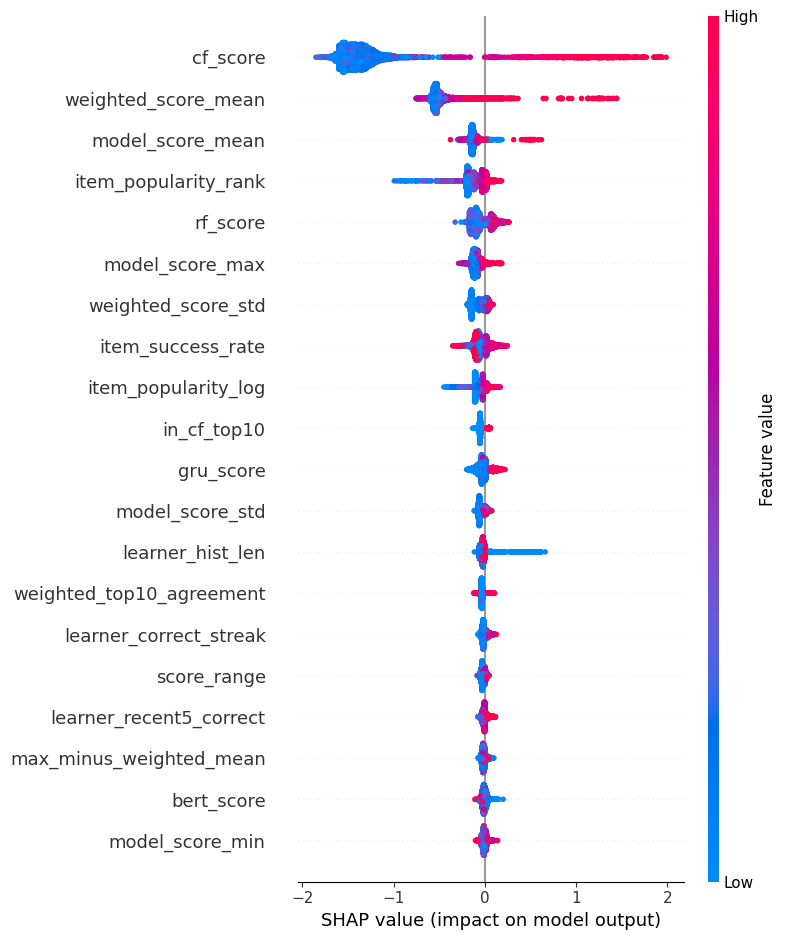

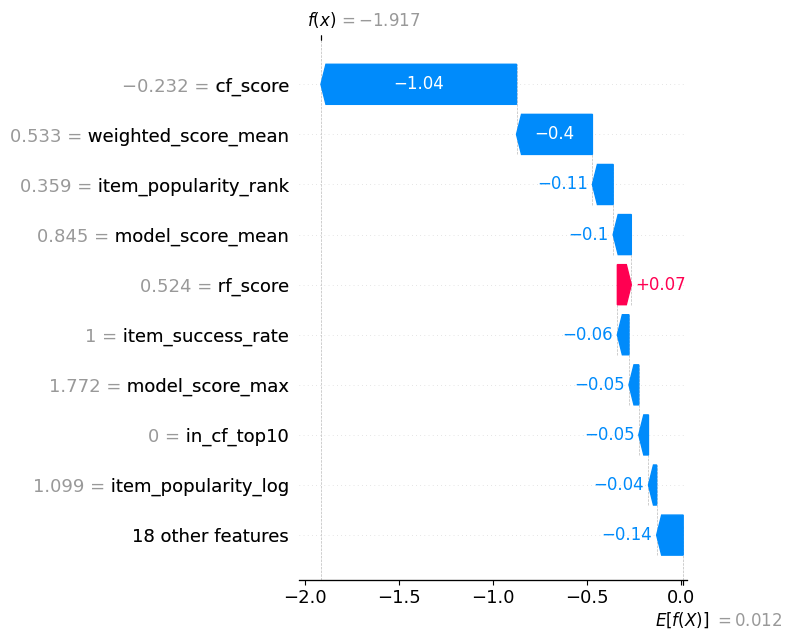

In [22]:
# ============================================================
# 22. SHAP ATTRIBUTION OF THE FINAL FROZEN XGBRANKER
# ============================================================
import matplotlib.pyplot as plt

if RUN_SHAP:
    try:
        import shap

        shap_sample = final_val_frame[
            FINAL_FEATURES
        ].sample(
            min(5_000, len(final_val_frame)),
            random_state=SEED
        )

        explainer = shap.TreeExplainer(
            xgb_model
        )

        shap_values = explainer.shap_values(
            shap_sample
        )

        mean_abs = np.abs(
            shap_values
        ).mean(axis=0)

        shap_df = pd.DataFrame({
            "Feature": FINAL_FEATURES,
            "MeanAbsSHAP": mean_abs,
        }).sort_values(
            "MeanAbsSHAP",
            ascending=False
        )

        total = shap_df[
            "MeanAbsSHAP"
        ].sum()

        shap_df[
            "RelativeImportance"
        ] = (
            shap_df["MeanAbsSHAP"]
            / total
            if total > 0
            else 0.0
        )

        display(
            shap_df.head(30)
        )

        shap_df.to_csv(
            OUT_DIR/"assistments_shap_importance.csv",
            index=False
        )

        shap.summary_plot(
            shap_values,
            shap_sample,
            show=False
        )

        plt.tight_layout()
        plt.savefig(
            OUT_DIR/"assistments_shap_summary.png",
            dpi=600,
            bbox_inches="tight"
        )
        plt.show()

        positive_rows = final_test_frame[
            final_test_frame.label == 1
        ]

        if len(positive_rows):
            rep_idx = positive_rows.index[
                len(positive_rows) // 2
            ]

            rep_x = final_test_frame.loc[
                [rep_idx],
                FINAL_FEATURES
            ]

            rep_sv = explainer(
                rep_x
            )

            shap.plots.waterfall(
                rep_sv[0],
                show=False
            )

            plt.tight_layout()
            plt.savefig(
                OUT_DIR/"assistments_shap_waterfall.png",
                dpi=600,
                bbox_inches="tight"
            )
            plt.show()

    except Exception as exc:
        shap_df = pd.DataFrame()
        print("SHAP analysis skipped due to:", repr(exc))
else:
    shap_df = pd.DataFrame()
    print("RUN_SHAP=False; SHAP analysis disabled.")

In [23]:
# ============================================================
# 23. ROBUSTNESS BY PRE-TEST HISTORY LENGTH
# ============================================================
def history_group(n):
    if n <= 5:
        return "Very Short (<=5)"
    if n <= 20:
        return "Short (6-20)"
    if n <= 50:
        return "Medium (21-50)"
    return "Long (>50)"

pretest_len = {
    int(u): len(test_history[int(u)])
    for u in eval_users
}

rob_rows = []

for model, d in per_user.items():
    x = d.copy()

    x["HistoryGroup"] = x.user_idx.map(
        lambda u: history_group(
            pretest_len[int(u)]
        )
    )

    for grp, g in x.groupby(
        "HistoryGroup"
    ):
        for metric in [
            "hr",
            "ndcg",
            "mrr"
        ]:
            if len(g) >= 2:
                lo, hi = bootstrap_ci(
                    g[metric].values,
                    n_boot=1000,
                    seed=SEED + len(rob_rows) + 900
                )
            else:
                lo, hi = np.nan, np.nan

            rob_rows.append({
                "Model": model,
                "HistoryGroup": grp,
                "Metric": metric,
                "Mean": g[metric].mean(),
                "CI_low": lo,
                "CI_high": hi,
                "Users": len(g),
                "Reliable_n_ge_30": len(g) >= 30,
            })

robustness_df = pd.DataFrame(
    rob_rows
)

display(
    robustness_df[
        robustness_df.Metric == "ndcg"
    ]
)

robustness_df.to_csv(
    OUT_DIR/"assistments_history_robustness.csv",
    index=False
)

,Model,HistoryGroup,Metric,Mean,CI_low,CI_high,Users,Reliable_n_ge_30
1,CF,Medium (21-50),ndcg,0.492700,0.477899,0.510772,2008,True
4,CF,Short (6-20),ndcg,0.524088,0.503636,0.543837,1213,True
7,CF,Very Short (<=5),ndcg,0.545298,0.500403,0.589820,344,True
10,RF,Medium (21-50),ndcg,0.349394,0.330556,0.366363,2008,True
13,RF,Short (6-20),ndcg,0.357396,0.333133,0.380823,1213,True
16,RF,Very Short (<=5),ndcg,0.312452,0.271151,0.357157,344,True
19,GRU4Rec,Medium (21-50),ndcg,0.175214,0.162128,0.187743,2008,True
22,GRU4Rec,Short (6-20),ndcg,0.280130,0.261224,0.299793,1213,True
25,GRU4Rec,Very Short (<=5),ndcg,0.232135,0.193613,0.270254,344,True
28,SASRec,Medium (21-50),ndcg,0.164144,0.151366,0.176885,2008,True


In [24]:
# ============================================================
# 24. CONTROLLED NEURAL TRAINING-DATA SCALING SENSITIVITY
# ============================================================
# This is a diagnostic experiment. It does not replace the principal
# all-common-cohort baseline table.

def nested_scaling_sizes(n_common):
    vals = []

    for frac in SCALING_FRACTIONS:
        n = int(round(
            n_common * frac
        ))
        n = min(
            n_common,
            max(200, n)
        )
        vals.append(n)

    vals[-1] = n_common
    return sorted(set(vals))

def cases_for_users(users):
    user_set = set(
        map(int, users)
    )

    return [
        (uid, prefix, target)
        for uid, prefix, target in common_neural_cases
        if int(uid) in user_set
    ]

def eval_neural_model(
    model_name,
    model,
    eval_subset
):
    rows = []

    for r in eval_subset.itertuples(
        index=False
    ):
        uid = int(r.user_idx)
        cand = val_candidates[uid]
        hist = val_history[uid]
        truth = int(r.item_idx)

        if model_name == "GRU4Rec":
            s = torch.tensor(
                [right_pad(hist, GRU_MAX_LEN)],
                dtype=torch.long,
                device=DEVICE
            )
            model.eval()
            with torch.no_grad():
                logits = model(s)[0]

        elif model_name == "SASRec":
            s = torch.tensor(
                [right_pad(hist, SAS_MAX_LEN)],
                dtype=torch.long,
                device=DEVICE
            )
            model.eval()
            with torch.no_grad():
                logits = model(s)[0]

        else:
            prefix = [
                int(x)
                for x in hist[
                    -(BERT_MAX_LEN - 1):
                ]
            ]

            arr = (
                prefix
                + [MASK_IDX]
                + [0] * (
                    BERT_MAX_LEN
                    - len(prefix)
                    - 1
                )
            )

            pos = len(prefix)

            s = torch.tensor(
                [arr],
                dtype=torch.long,
                device=DEVICE
            )

            p = torch.tensor(
                [pos],
                dtype=torch.long,
                device=DEVICE
            )

            model.eval()

            with torch.no_grad():
                logits = model(s, p)[0]

        idx = torch.tensor(
            cand,
            dtype=torch.long,
            device=DEVICE
        )

        scores = (
            logits[idx]
            .detach()
            .cpu()
            .numpy()
        )

        pred = topk_from_scores(
            cand,
            scores,
            TOPK
        )

        rows.append(
            per_query_metrics(
                pred,
                truth,
                TOPK
            )
        )

    d = pd.DataFrame(rows)

    return d[
        ["hr", "ndcg", "mrr"]
    ].mean()

scaling_rows = []

if RUN_SCALING_DIAGNOSTIC:
    scaling_sizes = nested_scaling_sizes(
        COMMON_LEARNERS
    )

    scaling_user_order = (
        np.random.default_rng(
            SEED + 333
        )
        .permutation(
            common_users
        )
    )

    diagnostic_eval_n = min(
        SCALING_EVAL_USERS,
        len(eval_users)
    )

    diagnostic_eval_users = np.sort(
        np.random.default_rng(
            SEED + 334
        ).choice(
            eval_users,
            size=diagnostic_eval_n,
            replace=False
        )
    )

    diagnostic_eval = val_eval[
        val_eval.user_idx.isin(
            diagnostic_eval_users
        )
    ].copy()

    for n_users in scaling_sizes:
        users = scaling_user_order[
            :int(n_users)
        ]

        cases = cases_for_users(
            users
        )

        user_set = set(
            map(int, users)
        )

        n_interactions = int(
            common_train_df[
                common_train_df.user_idx.isin(
                    user_set
                )
            ].shape[0]
        )

        # GRU4Rec diagnostic
        ds = PrefixDataset(
            cases,
            GRU_MAX_LEN
        )

        dl = DataLoader(
            ds,
            batch_size=GRU_BATCH,
            shuffle=True,
            num_workers=0
        )

        m = GRU4RecModel(
            n_items
        ).to(DEVICE)

        o = torch.optim.Adam(
            m.parameters(),
            lr=1e-3
        )

        c = nn.CrossEntropyLoss()

        st = time.time()

        for ep in range(
            SCALING_EPOCHS
        ):
            m.train()

            for s, t in dl:
                s, t = (
                    s.to(DEVICE),
                    t.to(DEVICE)
                )

                o.zero_grad(
                    set_to_none=True
                )

                loss = c(
                    m(s),
                    t
                )

                loss.backward()

                nn.utils.clip_grad_norm_(
                    m.parameters(),
                    1.0
                )

                o.step()

        sm = eval_neural_model(
            "GRU4Rec",
            m,
            diagnostic_eval
        )

        scaling_rows.append([
            "GRU4Rec",
            n_users,
            n_interactions,
            len(cases),
            time.time() - st,
            *sm.tolist()
        ])

        del m, ds, dl
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # SASRec diagnostic
        ds = PrefixDataset(
            cases,
            SAS_MAX_LEN
        )

        dl = DataLoader(
            ds,
            batch_size=SAS_BATCH,
            shuffle=True,
            num_workers=0
        )

        m = SASRecModel(
            n_items
        ).to(DEVICE)

        o = torch.optim.AdamW(
            m.parameters(),
            lr=1e-3,
            weight_decay=1e-5
        )

        c = nn.CrossEntropyLoss()

        st = time.time()

        for ep in range(
            SCALING_EPOCHS
        ):
            m.train()

            for s, t in dl:
                s, t = (
                    s.to(DEVICE),
                    t.to(DEVICE)
                )

                o.zero_grad(
                    set_to_none=True
                )

                loss = c(
                    m(s),
                    t
                )

                loss.backward()

                nn.utils.clip_grad_norm_(
                    m.parameters(),
                    1.0
                )

                o.step()

        sm = eval_neural_model(
            "SASRec",
            m,
            diagnostic_eval
        )

        scaling_rows.append([
            "SASRec",
            n_users,
            n_interactions,
            len(cases),
            time.time() - st,
            *sm.tolist()
        ])

        del m, ds, dl
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # BERT4Rec-style diagnostic
        ds = BERTTerminalDataset(
            cases
        )

        dl = DataLoader(
            ds,
            batch_size=BERT_BATCH,
            shuffle=True,
            num_workers=0
        )

        m = BERT4RecStyleModel(
            n_items
        ).to(DEVICE)

        o = torch.optim.AdamW(
            m.parameters(),
            lr=1e-3,
            weight_decay=1e-5
        )

        c = nn.CrossEntropyLoss()

        st = time.time()

        for ep in range(
            SCALING_EPOCHS
        ):
            m.train()

            for s, p, t in dl:
                s, p, t = (
                    s.to(DEVICE),
                    p.to(DEVICE),
                    t.to(DEVICE)
                )

                o.zero_grad(
                    set_to_none=True
                )

                loss = c(
                    m(s, p),
                    t
                )

                loss.backward()

                nn.utils.clip_grad_norm_(
                    m.parameters(),
                    1.0
                )

                o.step()

        sm = eval_neural_model(
            "BERT4Rec-style",
            m,
            diagnostic_eval
        )

        scaling_rows.append([
            "BERT4Rec-style",
            n_users,
            n_interactions,
            len(cases),
            time.time() - st,
            *sm.tolist()
        ])

        del m, ds, dl
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    scaling_df = pd.DataFrame(
        scaling_rows,
        columns=[
            "Model",
            "Learners",
            "TrainingInteractions",
            "PositivePrefixCases",
            "TrainingSeconds",
            "HR@10",
            "NDCG@10",
            "MRR@10",
        ]
    )

    display(scaling_df)

    scaling_df.to_csv(
        OUT_DIR/"assistments_neural_scaling.csv",
        index=False
    )

    scaling_effect_rows = []

    for model_name, g in scaling_df.groupby("Model"):
        g = g.sort_values("Learners")
        first = g.iloc[0]
        last = g.iloc[-1]

        scaling_effect_rows.append({
            "Model": model_name,
            "SmallestLearners": int(first["Learners"]),
            "LargestLearners": int(last["Learners"]),
            "NDCG@10_small": float(first["NDCG@10"]),
            "NDCG@10_large": float(last["NDCG@10"]),
            "DeltaNDCG@10": float(
                last["NDCG@10"]
                - first["NDCG@10"]
            ),
            "HR@10_small": float(first["HR@10"]),
            "HR@10_large": float(last["HR@10"]),
            "DeltaHR@10": float(
                last["HR@10"]
                - first["HR@10"]
            ),
            "MRR@10_small": float(first["MRR@10"]),
            "MRR@10_large": float(last["MRR@10"]),
            "DeltaMRR@10": float(
                last["MRR@10"]
                - first["MRR@10"]
            ),
        })

    scaling_effect_df = pd.DataFrame(
        scaling_effect_rows
    )

    display(scaling_effect_df)

    scaling_effect_df.to_csv(
        OUT_DIR/"assistments_neural_scaling_effect.csv",
        index=False
    )

else:
    scaling_df = pd.DataFrame()
    scaling_effect_df = pd.DataFrame()
    print("Scaling diagnostic disabled.")

,Model,Learners,TrainingInteractions,PositivePrefixCases,TrainingSeconds,HR@10,NDCG@10,MRR@10
0,GRU4Rec,960,27462,1898,1.851407,0.252,0.142501,0.109058
1,SASRec,960,27462,1898,2.542881,0.254,0.137593,0.102495
2,BERT4Rec-style,960,27462,1898,4.249718,0.252,0.133722,0.097324
3,GRU4Rec,1920,54924,3793,3.068996,0.310,0.179454,0.139876
4,SASRec,1920,54924,3793,3.507279,0.312,0.170982,0.128521
5,BERT4Rec-style,1920,54924,3793,6.633064,0.313,0.169851,0.126883
6,GRU4Rec,3840,108350,7584,5.312389,0.357,0.209825,0.164711
7,SASRec,3840,108350,7584,5.520106,0.339,0.205509,0.164889
8,BERT4Rec-style,3840,108350,7584,11.231364,0.326,0.188418,0.146693


,Model,SmallestLearners,LargestLearners,NDCG@10_small,NDCG@10_large,DeltaNDCG@10,HR@10_small,HR@10_large,DeltaHR@10,MRR@10_small,MRR@10_large,DeltaMRR@10
0,BERT4Rec-style,960,3840,0.133722,0.188418,0.054696,0.252,0.326,0.074,0.097324,0.146693,0.049369
1,GRU4Rec,960,3840,0.142501,0.209825,0.067324,0.252,0.357,0.105,0.109058,0.164711,0.055653
2,SASRec,960,3840,0.137593,0.205509,0.067916,0.254,0.339,0.085,0.102495,0.164889,0.062394


In [25]:
# ============================================================
# 25. COMPUTATIONAL EFFICIENCY, MODEL SIZE AND QUERY LATENCY
# ============================================================
def model_size_mb(obj):
    with tempfile.NamedTemporaryFile(
        delete=False,
        suffix=".bin"
    ) as f:
        path = f.name

    try:
        if isinstance(obj, nn.Module):
            torch.save(
                obj.state_dict(),
                path
            )
        else:
            with open(
                path,
                "wb"
            ) as g:
                pickle.dump(
                    obj,
                    g
                )

        return os.path.getsize(
            path
        ) / (1024**2)

    finally:
        try:
            os.remove(path)
        except Exception:
            pass

def torch_params(m):
    return sum(
        p.numel()
        for p in m.parameters()
    )

def benchmark_base(
    name,
    n_queries=300
):
    vals = []

    subset = test_eval.head(
        min(
            n_queries,
            len(test_eval)
        )
    )

    for r in subset.itertuples(
        index=False
    ):
        uid = int(r.user_idx)
        cand = test_candidates[uid]
        hist = test_history[uid]
        corr = test_correct_history[uid]

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        st = time.perf_counter()

        if name == "CF":
            cf_score(uid, cand, hist)
        elif name == "RF":
            rf_score(uid, cand, hist, corr)
        elif name == "GRU4Rec":
            gru_score(uid, cand, hist)
        elif name == "SASRec":
            sas_score(uid, cand, hist)
        elif name == "BERT4Rec-style":
            bert_score(uid, cand, hist)
        else:
            raise ValueError(name)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        vals.append(
            (time.perf_counter() - st)
            * 1000
        )

    return (
        float(np.mean(vals)),
        float(np.percentile(vals, 95))
    )

lat = {
    name: benchmark_base(name)
    for name in [
        "CF",
        "RF",
        "GRU4Rec",
        "SASRec",
        "BERT4Rec-style",
    ]
}

def benchmark_ranker(
    n_queries=300
):
    vals = []

    groups = list(
        final_test_frame.groupby(
            "query_id",
            sort=True
        )
    )[:n_queries]

    for _, g in groups:
        st = time.perf_counter()

        xgb_model.predict(
            g[FINAL_FEATURES]
        )

        vals.append(
            (time.perf_counter() - st)
            * 1000
        )

    return (
        float(np.mean(vals)),
        float(np.percentile(vals, 95))
    )

lat["XGBRanker"] = benchmark_ranker()

training_times = {
    "CF": cf_train_time,
    "RF": rf_train_time,
    "GRU4Rec": gru_train_time,
    "SASRec": sas_train_time,
    "BERT4Rec-style": bert_train_time,
    "XGBRanker": xgb_train_time,
}

objs = {
    "RF": rf_model,
    "GRU4Rec": gru_model,
    "SASRec": sas_model,
    "BERT4Rec-style": bert_model,
    "XGBRanker": xgb_model,
}

eff_rows = []

for name in [
    "CF",
    "RF",
    "GRU4Rec",
    "SASRec",
    "BERT4Rec-style",
    "XGBRanker",
]:
    obj = objs.get(name)

    params = (
        torch_params(obj)
        if isinstance(obj, nn.Module)
        else np.nan
    )

    trees = (
        len(obj.estimators_)
        if name == "RF"
        else (
            len(
                obj.get_booster().get_dump()
            )
            if name == "XGBRanker"
            else np.nan
        )
    )

    size = (
        model_size_mb(obj)
        if obj is not None
        else np.nan
    )

    meanlat, p95 = lat[name]

    gpu_peak = {
        "GRU4Rec": gru_peak_gpu_mb,
        "SASRec": sas_peak_gpu_mb,
        "BERT4Rec-style": bert_peak_gpu_mb,
    }.get(name, np.nan)

    eff_rows.append([
        name,
        training_times[name],
        meanlat,
        p95,
        size,
        params,
        trees,
        gpu_peak,
    ])

efficiency_df = pd.DataFrame(
    eff_rows,
    columns=[
        "Model",
        "TrainingSeconds",
        "MeanQueryLatencyMs",
        "P95QueryLatencyMs",
        "SerializedSizeMB",
        "Parameters",
        "TreeCount",
        "PeakGPUAllocatedMB",
    ]
)

complete = pd.DataFrame([{
    "Model": "Complete Hybrid",
    "TrainingSeconds": sum(
        training_times.values()
    ),
    "MeanQueryLatencyMs": sum(
        lat[n][0]
        for n in [
            "CF",
            "RF",
            "GRU4Rec",
            "SASRec",
            "BERT4Rec-style",
            "XGBRanker",
        ]
    ),
    "P95QueryLatencyMs": np.nan,
    "SerializedSizeMB": sum(
        model_size_mb(
            objs[n]
        )
        for n in objs
    ),
    "Parameters": sum(
        torch_params(m)
        for m in [
            gru_model,
            sas_model,
            bert_model,
        ]
    ),
    "TreeCount": (
        len(rf_model.estimators_)
        + len(
            xgb_model
            .get_booster()
            .get_dump()
        )
    ),
    "PeakGPUAllocatedMB": np.nan,
}])

efficiency_df = pd.concat(
    [efficiency_df, complete],
    ignore_index=True
)

display(efficiency_df)

efficiency_df.to_csv(
    OUT_DIR/"assistments_efficiency.csv",
    index=False
)

,Model,TrainingSeconds,MeanQueryLatencyMs,P95QueryLatencyMs,SerializedSizeMB,Parameters,TreeCount,PeakGPUAllocatedMB
0,CF,0.813044,0.733311,1.008566,NaN,NaN,NaN,NaN
1,RF,1.526058,34.206370,40.070927,0.896627,NaN,120.0,NaN
2,GRU4Rec,14.509939,0.753748,0.866694,6.644536,1741121.0,NaN,52.357910
3,SASRec,11.551171,1.661027,2.391104,9.995128,2618545.0,NaN,88.851074
4,BERT4Rec-style,25.706177,1.726302,2.052222,6.676097,1748481.0,NaN,84.941895
5,XGBRanker,11.226431,3.631988,3.917183,0.747780,NaN,300.0,NaN
6,Complete Hybrid,65.332821,42.712746,NaN,24.960168,6108147.0,420.0,NaN


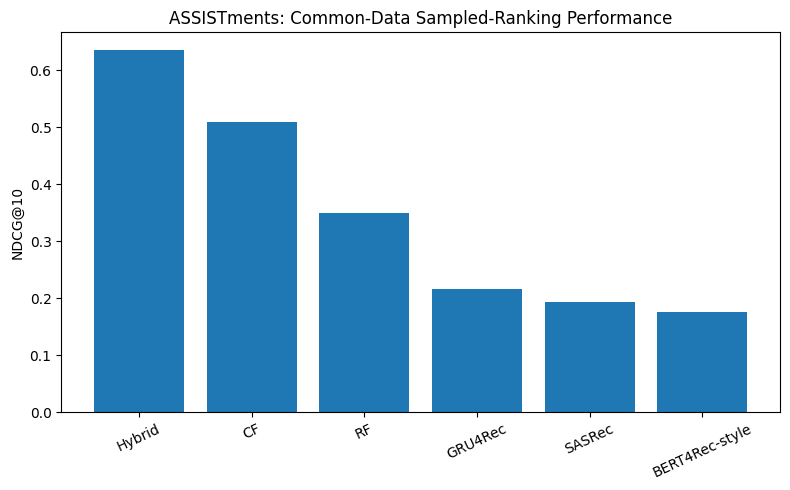

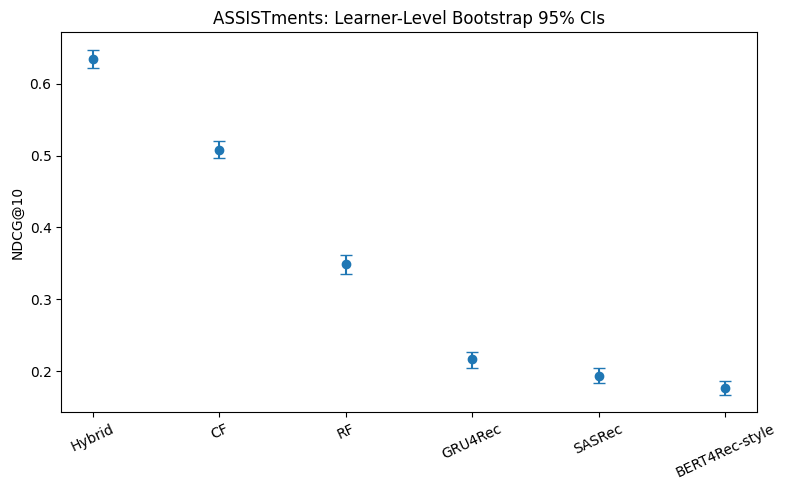

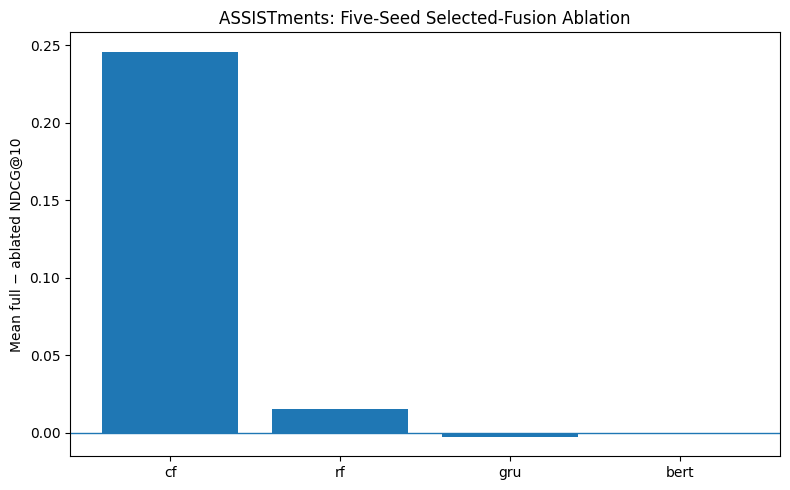

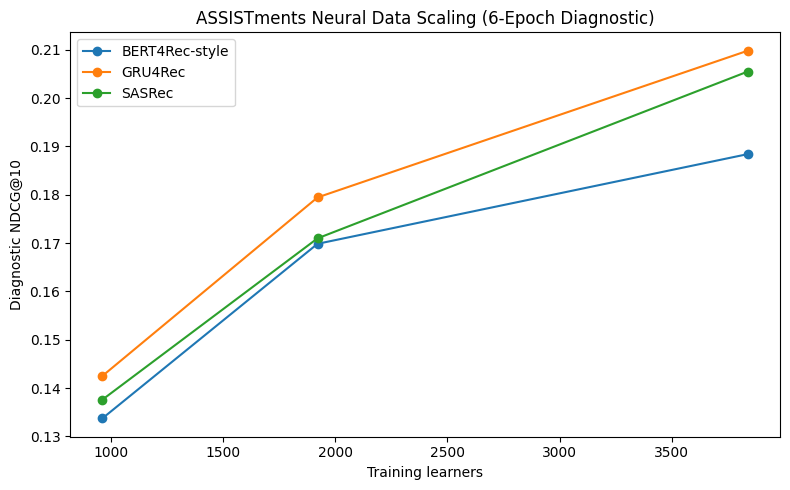

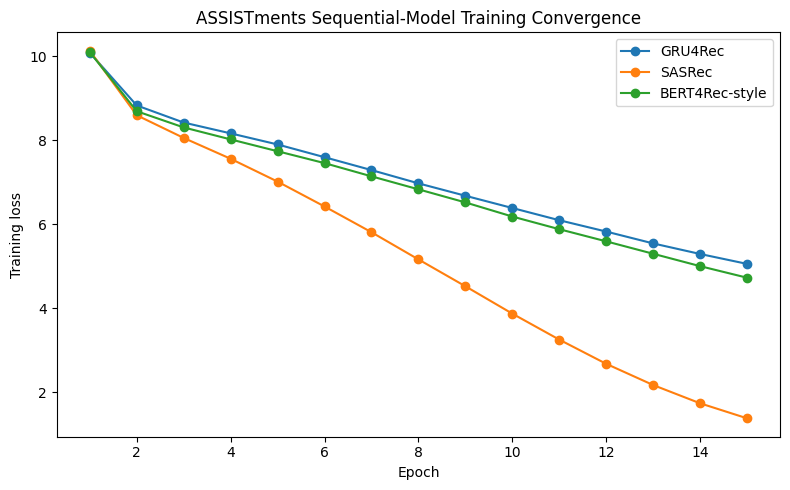

In [26]:
# ============================================================
# 26. PUBLICATION FIGURES
# ============================================================
import matplotlib.pyplot as plt

# Main NDCG performance
p = results_df.sort_values(
    "NDCG@10",
    ascending=False
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    p.Model,
    p["NDCG@10"]
)

ax.set_ylabel(
    "NDCG@10"
)

ax.set_title(
    "ASSISTments: Common-Data Sampled-Ranking Performance"
)

ax.tick_params(
    axis="x",
    rotation=25
)

fig.tight_layout()

fig.savefig(
    OUT_DIR/"assistments_main_ndcg.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# NDCG confidence intervals
nci = (
    ci_df[
        ci_df.Metric == "ndcg"
    ]
    .copy()
    .sort_values(
        "Mean",
        ascending=False
    )
)

yerr = np.vstack([
    nci["Mean"] - nci["CI_low"],
    nci["CI_high"] - nci["Mean"],
])

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.errorbar(
    nci["Model"],
    nci["Mean"],
    yerr=yerr,
    fmt="o",
    capsize=4
)

ax.set_ylabel(
    "NDCG@10"
)

ax.set_title(
    "ASSISTments: Learner-Level Bootstrap 95% CIs"
)

ax.tick_params(
    axis="x",
    rotation=25
)

fig.tight_layout()

fig.savefig(
    OUT_DIR/"assistments_ndcg_ci.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Five-seed ablation
if not ablation_summary.empty:
    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.bar(
        ablation_summary[
            "AblatedComponent"
        ],
        ablation_summary[
            "MeanFullMinusVariantNDCG"
        ]
    )

    ax.axhline(
        0,
        linewidth=1
    )

    ax.set_ylabel(
        "Mean full − ablated NDCG@10"
    )

    ax.set_title(
        "ASSISTments: Five-Seed Selected-Fusion Ablation"
    )

    fig.tight_layout()

    fig.savefig(
        OUT_DIR/"assistments_ablation_ndcg.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

# Neural data-scaling sensitivity
if (
    RUN_SCALING_DIAGNOSTIC
    and not scaling_df.empty
):
    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    for model, g in scaling_df.groupby(
        "Model"
    ):
        g = g.sort_values(
            "Learners"
        )

        ax.plot(
            g["Learners"],
            g["NDCG@10"],
            marker="o",
            label=model
        )

    ax.set_xlabel(
        "Training learners"
    )

    ax.set_ylabel(
        "Diagnostic NDCG@10"
    )

    ax.set_title(
        f"ASSISTments Neural Data Scaling ({SCALING_EPOCHS}-Epoch Diagnostic)"
    )

    ax.legend()

    fig.tight_layout()

    fig.savefig(
        OUT_DIR/"assistments_neural_scaling.png",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

# Training convergence
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.plot(
    range(1, len(gru_losses) + 1),
    gru_losses,
    marker="o",
    label="GRU4Rec"
)

ax.plot(
    range(1, len(sas_losses) + 1),
    sas_losses,
    marker="o",
    label="SASRec"
)

ax.plot(
    range(1, len(bert_losses) + 1),
    bert_losses,
    marker="o",
    label="BERT4Rec-style"
)

ax.set_xlabel(
    "Epoch"
)

ax.set_ylabel(
    "Training loss"
)

ax.set_title(
    "ASSISTments Sequential-Model Training Convergence"
)

ax.legend()

fig.tight_layout()

fig.savefig(
    OUT_DIR/"assistments_training_convergence.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [27]:
# ============================================================
# 27. FINAL COMMON-COHORT / LEAKAGE / REPRODUCIBILITY GATE
# ============================================================
def user_hash(users):
    arr = np.array(
        sorted(
            set(
                map(
                    int,
                    users
                )
            )
        ),
        dtype=np.int64
    )

    return hashlib.sha256(
        ",".join(
            map(
                str,
                arr.tolist()
            )
        ).encode(
            "utf-8"
        )
    ).hexdigest()

expected_common_set = set(
    map(
        int,
        common_users
    )
)

# CF is verified from the dataframe actually consumed by the model.
cf_training_users = np.sort(
    CF_SOURCE_DF[
        "user_idx"
    ].unique().astype(
        np.int64
    )
)

training_user_sets = {
    "CF": set(
        map(
            int,
            cf_training_users
        )
    ),
    "RF": set(
        map(
            int,
            rf_training_users
        )
    ),
    "GRU4Rec": set(
        map(
            int,
            gru_training_users
        )
    ),
    "SASRec": set(
        map(
            int,
            sas_training_users
        )
    ),
    "BERT4Rec-style": set(
        map(
            int,
            bert_training_users
        )
    ),
}

model_train_hashes = {
    name: user_hash(users)
    for name, users
    in training_user_sets.items()
}

fairness_rows = []

for name, users in training_user_sets.items():
    fairness_rows.append({
        "Model": name,
        "TrainingLearners": len(users),
        "IdenticalToCommonCohort": (
            users
            == expected_common_set
        ),
        "VisitorSetSHA256": model_train_hashes[name],
    })

common_data_fairness_audit = pd.DataFrame(
    fairness_rows
)

display(
    common_data_fairness_audit
)

assert len(CF_SOURCE_DF) == len(common_train_df)
assert all(
    common_data_fairness_audit[
        "IdenticalToCommonCohort"
    ]
)
assert len(
    set(
        model_train_hashes.values()
    )
) == 1

rf_positive_cases = int(
    (
        rf_train.label == 1
    ).sum()
)

neural_positive_cases = len(
    common_neural_cases
)

validity_gate = pd.DataFrame([
    [
        "ASSISTments preprocessing and task transformation explicit",
        True
    ],
    [
        "Per-learner chronological leave-two-out",
        True
    ],
    [
        "Common cohort selected from training information only",
        True
    ],
    [
        "Same actual training-learner hash for all five baseline families",
        len(
            set(
                model_train_hashes.values()
            )
        ) == 1
    ],
    [
        "Same bounded training histories define all model evidence",
        True
    ],
    [
        "RF/neural positive prefix-case counts identical",
        rf_positive_cases
        == neural_positive_cases
    ],
    [
        "RF features are temporal-prefix safe",
        True
    ],
    [
        "Common training catalogue defines all negatives",
        True
    ],
    [
        "Exactly 1 positive + 99 negatives per query",
        bool(
            (
                candidate_audit[
                    "MeanCandidates"
                ]
                == NEGATIVES_PER_QUERY + 1
            ).all()
        )
    ],
    [
        "Same cached candidates for every model",
        True
    ],
    [
        "Validation target excluded from test negatives",
        True
    ],
    [
        "Reliability estimated from fusion-fit validation partition",
        True
    ],
    [
        "Backward component selection restricted to held-out validation partition",
        True
    ],
    [
        "Final component set frozen before final test evaluation",
        True
    ],
    [
        "Final ranker refit uses validation only",
        True
    ],
    [
        "Five-seed ablation retrains the ranker",
        len(ABLATION_SEEDS) == 5
        and len(ablation_runs) > 0
        and ablation_runs["Seed"].nunique() == 5
        and (
            ablation_runs
            .groupby("AblatedComponent")["Seed"]
            .nunique()
            .eq(5)
            .all()
        )
    ],
    [
        "Paired statistics + bootstrap + Holm + effect size included",
        True
    ],
    [
        "Popularity/context controls included",
        True
    ],
    [
        "SHAP attribution completed",
        (
            (not RUN_SHAP)
            or (
                "shap_df" in globals()
                and isinstance(shap_df, pd.DataFrame)
                and not shap_df.empty
            )
        )
    ],
    [
        "History-length robustness included",
        True
    ],
    [
        "Computational efficiency included",
        True
    ],
    [
        "Controlled neural scaling sensitivity included",
        (
            (not RUN_SCALING_DIAGNOSTIC)
            or (
                "scaling_df" in globals()
                and isinstance(scaling_df, pd.DataFrame)
                and not scaling_df.empty
                and scaling_df["Model"].nunique() == 3
            )
        )
    ],
], columns=[
    "ValidityCheck",
    "Passed"
])

display(validity_gate)

assert validity_gate[
    "Passed"
].all(), (
    "At least one final validity gate failed."
)

fingerprints = {
    "common_cohort_original_sha256": COMMON_COHORT_ORIGINAL_SHA256,
    "common_cohort_sha256": COMMON_COHORT_SHA256,
    "common_history_sha256": COMMON_HISTORY_SHA256,
    "evaluation_users_sha256": EVAL_USERS_SHA256,
    "common_learners": int(COMMON_LEARNERS),
    "common_history_cap": int(COMMON_MAX_HISTORY),
    "common_prefix_cases": int(
        len(common_prefix_cases)
    ),
    "evaluation_queries": int(
        EVAL_USER_COUNT
    ),
    "selected_components": SELECTED_COMPONENTS,
    "final_feature_count": int(
        len(FINAL_FEATURES)
    ),
    "ranker_objective": RANKER_PARAMS[
        "objective"
    ],
    "ablation_seeds": ABLATION_SEEDS,
}

with open(
    OUT_DIR/"assistments_fingerprints.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        fingerprints,
        f,
        indent=2
    )

common_data_fairness_audit.to_csv(
    OUT_DIR/"assistments_common_data_fairness_audit.csv",
    index=False
)

validity_gate.to_csv(
    OUT_DIR/"assistments_validity_gate.csv",
    index=False
)

print(
    json.dumps(
        fingerprints,
        indent=2
    )
)

print(
    "FINAL COMMON-DATA FAIRNESS / LEAKAGE GATE: PASSED"
)

print(
    "All five baseline families use the same underlying common learner cohort."
)

print(
    "FINAL OUTPUT DIRECTORY:",
    OUT_DIR
)

,Model,TrainingLearners,IdenticalToCommonCohort,VisitorSetSHA256
0,CF,3840,True,337e693b355639d663b6e9f6b0fb686b9ae543f45c46d7...
1,RF,3840,True,337e693b355639d663b6e9f6b0fb686b9ae543f45c46d7...
2,GRU4Rec,3840,True,337e693b355639d663b6e9f6b0fb686b9ae543f45c46d7...
3,SASRec,3840,True,337e693b355639d663b6e9f6b0fb686b9ae543f45c46d7...
4,BERT4Rec-style,3840,True,337e693b355639d663b6e9f6b0fb686b9ae543f45c46d7...


,ValidityCheck,Passed
0,ASSISTments preprocessing and task transformat...,True
1,Per-learner chronological leave-two-out,True
2,Common cohort selected from training informati...,True
3,Same actual training-learner hash for all five...,True
4,Same bounded training histories define all mod...,True
5,RF/neural positive prefix-case counts identical,True
6,RF features are temporal-prefix safe,True
7,Common training catalogue defines all negatives,True
8,Exactly 1 positive + 99 negatives per query,True
9,Same cached candidates for every model,True


{
  "common_cohort_original_sha256": "5c8fa5a35ad4caba8cd457e51c6a2d157afb045a283416ecfb987ab00e78a67d",
  "common_cohort_sha256": "337e693b355639d663b6e9f6b0fb686b9ae543f45c46d73ddc02ae2c97a0e5b5",
  "common_history_sha256": "f3d962d7f358b25fe0b04b76ef7cbd83dbdd86a6d55fb550d398b84295af5849",
  "evaluation_users_sha256": "a99d203f34f93a8bbfd9a89d73e22b36cfa63fafe40f37bcc93236d5b4cb3355",
  "common_learners": 3840,
  "common_history_cap": 50,
  "common_prefix_cases": 7584,
  "evaluation_queries": 3565,
  "selected_components": [
    "cf",
    "rf",
    "gru",
    "bert"
  ],
  "final_feature_count": 27,
  "ranker_objective": "rank:ndcg",
  "ablation_seeds": [
    42,
    59,
    73,
    89,
    115
  ]
}
FINAL COMMON-DATA FAIRNESS / LEAKAGE GATE: PASSED
All five baseline families use the same underlying common learner cohort.
FINAL OUTPUT DIRECTORY: /kaggle/working/assistments_common_cohort_publication_outputs


In [28]:
# ============================================================
# 28. ENVIRONMENT CAPTURE + MANUSCRIPT-READY RUN SUMMARY
# ============================================================
print("=" * 76)
print("FINAL EXECUTED ENVIRONMENT")
print("=" * 76)
print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )
    print(
        "CUDA version:",
        torch.version.cuda
    )

lock_file = OUT_DIR/"requirements-lock.txt"

with open(
    lock_file,
    "w",
    encoding="utf-8"
) as f:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "freeze"
        ],
        stdout=f,
        check=True
    )

summary_lines = [
    "ASSISTMENTS COMMON-DATA PUBLICATION SUMMARY",
    f"Common cohort: {COMMON_LEARNERS:,} learners",
    f"Common bounded train interactions: {len(common_train_df):,}",
    f"Common catalogue items: {len(train_catalog):,}",
    f"Common positive prefix cases: {len(common_prefix_cases):,}",
    f"Evaluation queries: {EVAL_USER_COUNT:,}",
    "Candidate protocol: 1 positive + 99 uniform unseen negatives from common train catalogue",
    f"Validation fusion-fit queries: {len(fusion_fit_qids):,}",
    f"Validation component-selection queries: {len(selection_qids):,}",
    f"Selected fusion components: {', '.join(SELECTED_COMPONENTS)}",
    f"Final fusion features: {len(FINAL_FEATURES)}",
    f"Five-seed ablation seeds: {ABLATION_SEEDS}",
    f"Common cohort SHA256: {COMMON_COHORT_SHA256}",
    f"Common history SHA256: {COMMON_HISTORY_SHA256}",
    f"Evaluation users SHA256: {EVAL_USERS_SHA256}",
    "",
    "MAIN RESULTS",
    results_df.to_string(index=False),
]

summary_text = "\n".join(
    summary_lines
)

print(
    summary_text
)

with open(
    OUT_DIR/"assistments_publication_summary.txt",
    "w",
    encoding="utf-8"
) as f:
    f.write(
        summary_text
    )

print(
    "\nExact package environment saved to:",
    lock_file
)

print("=" * 76)

FINAL EXECUTED ENVIRONMENT
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
ASSISTMENTS COMMON-DATA PUBLICATION SUMMARY
Common cohort: 3,840 learners
Common bounded train interactions: 108,350
Common catalogue items: 20,342
Common positive prefix cases: 7,584
Evaluation queries: 3,565
Candidate protocol: 1 positive + 99 uniform unseen negatives from common train catalogue
Validation fusion-fit queries: 2,852
Validation component-selection queries: 713
Selected fusion components: cf, rf, gru, bert
Final fusion features: 27
Five-seed ablation seeds: [42, 59, 73, 89, 115]
Common cohort SHA256: 337e693b355639d663b6e9f6b0fb686b9ae543f45c46d73ddc02ae2c97a0e5b5
Common history SHA256: f3d962d7f358b25fe0b04b76ef7cbd83dbdd86a6d55fb550d398b84295af5849
Evaluation users SHA256: a99d203f34f93a8bbfd9a89d73e22b36cfa63fafe40f37bcc93236d5b4cb3355

MAIN RESULTS
         Mod